# **Taller Asociación**
---

**Minería de Datos**

*Profesora Elizabeth Leon Guzmán*

Universidad Nacional de Colombia


| **Estudiante** | **Correo Institucional** |
|---|---|
| Nicolás Martínez López | nmartinezl@unal.edu.co |

---

# **Librerías**

In [54]:
%pip install pyfpgrowth
%pip install efficient-apriori

Librerías permitidas en la utilización del taller

In [55]:
import numpy as np
import pandas as pd
import pyfpgrowth
import time
from efficient_apriori import apriori
from sklearn import preprocessing
from scipy import stats

# **Punto 1**

In [56]:
## Importar Dataset MarketBasket
data = """ID\tLeche\tCerveza\tPañales\tPan\tMantequilla\tGalletas
1\tTRUE\tTRUE\tTRUE\tFALSE\tFALSE\tFALSE
2\tTRUE\tFALSE\tFALSE\tTRUE\tTRUE\tFALSE
3\tTRUE\tFALSE\tTRUE\tFALSE\tFALSE\tTRUE
4\tFALSE\tFALSE\tFALSE\tTRUE\tTRUE\tTRUE
5\tFALSE\tTRUE\tTRUE\tFALSE\tFALSE\tTRUE
6\tTRUE\tFALSE\tTRUE\tTRUE\tTRUE\tFALSE
7\tFALSE\tFALSE\tTRUE\tTRUE\tTRUE\tFALSE
8\tFALSE\tTRUE\tTRUE\tFALSE\tFALSE\tFALSE
9\tTRUE\tFALSE\tTRUE\tTRUE\tTRUE\tFALSE
10\tFALSE\tTRUE\tFALSE\tFALSE\tFALSE\tTRUE"""

data_lines = data.strip().split('\n')
headers = data_lines[0].split('\t')

rows = []
for line in data_lines[1:]:
    values = line.split('\t')
    processed_values = [values[0]] + [True if v == 'TRUE' else (False if v == 'FALSE' else v) for v in values[1:]]
    rows.append(processed_values)

df_market_basket = pd.DataFrame(rows, columns=headers)

display(df_market_basket)

,ID,Leche,Cerveza,Pañales,Pan,Mantequilla,Galletas
0,1,True,True,True,False,False,False
1,2,True,False,False,True,True,False
2,3,True,False,True,False,False,True
3,4,False,False,False,True,True,True
4,5,False,True,True,False,False,True
5,6,True,False,True,True,True,False
6,7,False,False,True,True,True,False
7,8,False,True,True,False,False,False
8,9,True,False,True,True,True,False
9,10,False,True,False,False,False,True


Por cada una de las siguientes preguntas, proveer un ejemplo de una regla de asociación del dominio de "market basket" que satisface las siguientes condiciones. También, describir si las reglas son interesantes (subjetivamente).

In [57]:
def get_n_itemset_rules(df, n):
    """
    Genera y retorna reglas de asociación con n itemsets (n-1 en antecedente, 1 en consecuente)
    junto con su soporte y confianza.

    Parámetros:
    df (pd.DataFrame): DataFrame de transacciones en formato booleano (ej. df_market_basket).
                       Las columnas representan los ítems, y los valores TRUE/FALSE indican
                       la presencia del ítem en la transacción.
    n (int): El número total de ítems en la regla (n-1 en el antecedente y 1 en el consecuente).
             Debe estar entre 2 y el número de columnas de ítems del DataFrame (excluyendo 'ID').

    Retorna:
    list: Una lista de diccionarios, donde cada diccionario contiene la regla (antecedente, consecuente),
          su soporte y su confianza.
    """
    # Asumiendo que la primera columna es 'ID' y el resto son ítems
    item_cols = df.columns[1:]
    num_item_cols = len(item_cols)

    # 1. Validar n
    if not (2 <= n <= num_item_cols):
        raise ValueError(f"El número de itemsets 'n' debe estar entre 2 y {num_item_cols} (número de columnas de ítems).")

    # 2. Convertir DataFrame a formato de transacciones
    transactions = []
    for _, row in df.iterrows():
        transaction = [item for item in item_cols if row[item]]
        if transaction: # Solo añadir transacciones con al menos un ítem
            transactions.append(transaction)

    if not transactions:
        return [] # No hay transacciones para procesar

    # 3. Ejecutar Apriori para encontrar itemsets frecuentes y reglas de asociación
    # Usamos min_support y min_confidence bajos para asegurar que se generen la mayoría de las reglas
    # y luego podamos filtrarlas por el tamaño 'n' especificado.
    try:
        itemsets, rules = apriori(transactions, min_support=0.01, min_confidence=0.01)
    except Exception as e:
        print(f"Error al ejecutar Apriori: {e}")
        return []

    # 4. Filtrar reglas que tienen n-1 items en el antecedente y 1 item en el consecuente
    n_itemset_rules = []
    for rule in rules:
        # La longitud del antecedente debe ser n-1 y la del consecuente debe ser 1
        if len(rule.lhs) == n - 1 and len(rule.rhs) == 1:
            n_itemset_rules.append({
                'antecedente': sorted(list(rule.lhs)), # Ordenar para consistencia
                'consecuente': list(rule.rhs)[0],     # El consecuente es un único ítem
                'soporte': rule.support,
                'confianza': rule.confidence
            })

    return n_itemset_rules

In [58]:
rules = {}
for n_val in range(2, 7): # Iterar desde n=2 hasta n=6 que es el número de columnas que tiene el dataset
    print(f"\nReglas de asociación con n={n_val} itemsets:")
    try:
        rules_for_n = get_n_itemset_rules(df_market_basket, n_val)
        rules[n_val] = rules_for_n
        if rules_for_n:
            for rule in rules_for_n:
                print(f"Antecedente: {rule['antecedente']}, Consecuente: {rule['consecuente']}, "
                      f"Soporte: {rule['soporte']:.3f}, Confianza: {rule['confianza']:.3f}")
        else:
            print(f"No se encontraron reglas para n={n_val} itemsets.")
    except ValueError as e:
        print(e)


Reglas de asociación con n=2 itemsets:
Antecedente: ['Galletas'], Consecuente: Cerveza, Soporte: 0.200, Confianza: 0.500
Antecedente: ['Cerveza'], Consecuente: Galletas, Soporte: 0.200, Confianza: 0.500
Antecedente: ['Leche'], Consecuente: Cerveza, Soporte: 0.100, Confianza: 0.200
Antecedente: ['Cerveza'], Consecuente: Leche, Soporte: 0.100, Confianza: 0.250
Antecedente: ['Pañales'], Consecuente: Cerveza, Soporte: 0.300, Confianza: 0.429
Antecedente: ['Cerveza'], Consecuente: Pañales, Soporte: 0.300, Confianza: 0.750
Antecedente: ['Leche'], Consecuente: Galletas, Soporte: 0.100, Confianza: 0.200
Antecedente: ['Galletas'], Consecuente: Leche, Soporte: 0.100, Confianza: 0.250
Antecedente: ['Mantequilla'], Consecuente: Galletas, Soporte: 0.100, Confianza: 0.200
Antecedente: ['Galletas'], Consecuente: Mantequilla, Soporte: 0.100, Confianza: 0.250
Antecedente: ['Pan'], Consecuente: Galletas, Soporte: 0.100, Confianza: 0.200
Antecedente: ['Galletas'], Consecuente: Pan, Soporte: 0.100, Confi

## **Inciso A**

**Una regla que que tiene alto soporte y alta confianza**


Al observar las reglas de asociación obtenidas, la regla:

*   `{Pan} → Mantequilla`

destaca por tener un **soporte de 0.5** y una **confianza de 1.0**.

Esto significa lo siguiente:

*   **Soporte (0.5):** El 50% de todas las transacciones (5 de 10) en el dataset contienen tanto 'Pan' como 'Mantequilla'. Este es un valor alto, indicando que la combinación de estos dos ítems es muy frecuente.
*   **Confianza (1.0):** En el 100% de las transacciones donde se compra 'Pan', también se compra 'Mantequilla'. Esto sugiere una relación muy fuerte y predictiva: si un cliente compra 'Pan', es seguro que también comprará 'Mantequilla'.

Esta es una de las reglas con los valores más altos de soporte y confianza, lo que la hace particularmente interesante desde una perspectiva de negocio para promociones o colocación de productos.

## **Inciso B**

**Una regla que tiene razonablemente alto soporte pero baja confianza**

Al examinar las reglas de asociación, la siguiente regla sirve como un buen ejemplo de **razonablemente alto soporte pero baja confianza**:

*   `{Pañales} → Pan`

Con los siguientes valores:

*   **Soporte (0.300):** Este valor indica que el 30% de todas las transacciones en el dataset contienen tanto 'Pañales' como 'Pan'. Es uno de los soportes más altos encontrados entre todas las reglas, lo que sugiere que la co-ocurrencia de estos dos ítems es relativamente común. Puede explicarse porque ambos son productos de consumo masivo y esenciales en muchos hogares. Los pañales son una necesidad recurrente para familias con bebés, mientras que el pan es un alimento básico diario. Es natural que con frecuencia aparezcan juntos en las cestas de la compra simplemente porque los consumidores adquieren sus productos esenciales en una misma visita al supermercado.
*   **Confianza (0.429):** Esto significa que, en las transacciones donde se compran 'Pañales', solo el 42.9% de las veces también se compra 'Pan'. A pesar del alto soporte, una confianza por debajo del 50% es considerada baja en la práctica. Esto implica que la compra de 'Pañales' no es un predictor fuerte de la compra de 'Pan'. Esto sugiere que la compra de pañales no impulsa directamente la compra de pan. Un comprador de pañales podría ya tener pan en casa, preferir un tipo de pan diferente que compra en otro establecimiento, o simplemente no necesitar pan en ese momento específico. La decisión de compra de pan no está fuertemente "ligada" a la decisión de compra de pañales, a pesar de que ambos artículos son populares y se compran con frecuencia. Esto indica que no existe una relación causal fuerte o una complementariedad directa que haga que la presencia de pañales en el carrito prediga de manera confiable la presencia de pan.

## **Inciso C**
**Una regla que tiene bajo soporte y baja confianza**

Al examinar las reglas de asociación, la siguiente regla sirve como un buen ejemplo de **bajo soporte y baja confianza**:

*   `{Leche} → Cerveza`

Con los siguientes valores:

*   **Soporte (0.100):** Esto significa que solo el 10% de todas las transacciones en el dataset (1 de cada 10) contienen tanto 'Leche' como 'Cerveza'. Este es un valor relativamente bajo, lo que indica que la co-ocurrencia de estos dos ítems no es muy frecuente en el conjunto de datos.
*   **Confianza (0.200):** Esto implica que, en las transacciones donde se compra 'Leche', solo el 20% de las veces también se compra 'Cerveza'. Una confianza del 20% es bastante baja, sugiriendo que la compra de 'Leche' no es un buen predictor de la compra de 'Cerveza'. Es decir, la presencia del antecedente ('Leche') no lleva con alta probabilidad a la presencia del consecuente ('Cerveza').

## **Inciso D**
**Una regla que tiene bajo soporte y alta confianza**

Al analizar las reglas, se identifica la siguiente que cumple con la condición de **bajo soporte y alta confianza**:

*   `{Galletas, Pan} → Mantequilla`

Con los valores observados:

*   **Soporte (0.100):** Este valor indica que la combinación de comprar 'Galletas', 'Pan' y 'Mantequilla' juntos ocurre en solo el 10% de las transacciones totales. Es un valor bajo, lo que significa que esta combinación específica de tres ítems no es muy común en el dataset.
*   **Confianza (1.000):** Este dato es notable, ya que en el 100% de las ocasiones en que un cliente compra tanto 'Galletas' como 'Pan', también adquiere 'Mantequilla'. Es decir, si se compran estos dos antecedentes, la compra del consecuente ('Mantequilla') es una certeza.

En el mundo real, esta regla puede presentarse en escenarios específicos. Por ejemplo, en una cafetería o panadería, **la compra simultánea de 'Pan' (como pan artesanal para tostadas) y 'Galletas' puede implicar casi siempre la compra de 'Mantequilla'** si los clientes buscan un desayuno o merienda gourmet. El bajo soporte se debería a que no todos los clientes adquieren estos productos específicos juntos, pero quienes sí lo hacen, casi siempre completan la compra con la mantequilla que acompaña bien a ambos productos.

# **Punto 2**
¿Por qué el proceso de descubrimiento de reglas de asociación es relativamente simple comparado con la generación de
grandes conjuntos de ítems en bases de datos transaccionales?

El proceso de descubrimiento de reglas de asociación es relativamente simple porque trabaja sobre un conjunto de datos que ya ha sido reducido y filtrado previamente. Es decir, una vez se han identificado los conjuntos de ítems frecuentes, generar reglas consiste únicamente en dividir esos conjuntos en posibles antecedentes y consecuentes, y calcular métricas como soporte y confianza, lo cual implica operaciones directas y poco costosas computacionalmente. Por el contrario, la generación de grandes conjuntos de ítems frecuentes es la parte más compleja del proceso, ya que requiere explorar un espacio de búsqueda muy amplio. Esto se debe a que, en bases de datos transaccionales, el número de combinaciones posibles de ítems crece de manera exponencial conforme aumenta la cantidad de ítems. Para manejar esta complejidad, los algoritmos deben realizar múltiples recorridos sobre la base de datos y aplicar técnicas de poda, lo que incrementa significativamente el costo computacional. La diferencia radica en que la generación de conjuntos frecuentes implica un problema combinatorio costoso, mientras que la generación de reglas es un proceso más directo y eficiente una vez que dichos conjuntos ya han sido obtenidos.

# **Punto 3**
Considere el siguiente conjunto de datos:

In [59]:
data = [['TID', 'Items'],
        ['T01', 'milk, beer, diapers'],
        ['T02', 'bread, butter, milk'],
        ['T03', 'milk, diapers, cookies'],
        ['T04', 'bread, butter, cookies'],
        ['T05', 'beer, cookies, diapers'],
        ['T06', 'milk, diapers, bread, butter'],
        ['T07', 'bread, butter, diapers'],
        ['T08', 'beer, diapers'],
        ['T09', 'milk, diapers, bread, butter'],
        ['T10', 'beer, cookies']]

df_transactions = pd.DataFrame(data[1:], columns=data[0])
display(df_transactions)

,TID,Items
0,T01,"milk, beer, diapers"
1,T02,"bread, butter, milk"
2,T03,"milk, diapers, cookies"
3,T04,"bread, butter, cookies"
4,T05,"beer, cookies, diapers"
5,T06,"milk, diapers, bread, butter"
6,T07,"bread, butter, diapers"
7,T08,"beer, diapers"
8,T09,"milk, diapers, bread, butter"
9,T10,"beer, cookies"


## **Inciso A**
**¿cuál es el número máximo de reglas de asociación que se pueden generar? (incluyendo reglas con soporte 0)**


In [60]:
# Function to calculate combinations (C(n, k)) manually
def combinations(n, k):
    if k < 0 or k > n:
        return 0
    if k == 0 or k == n:
        return 1
    if k > n // 2: # Take advantage of symmetry C(n, k) = C(n, n-k)
        k = n - k

    res = 1
    for i in range(k):
        res = res * (n - i) // (i + 1)
    return res

# Extraer todos los ítems únicos del DataFrame df_transactions
all_items = set()
for items_str in df_transactions['Items']:
    for item in items_str.split(', '):
        all_items.add(item.strip())

num_unique_items = len(all_items)

print(f"Ítems únicos: {sorted(list(all_items))}")
print(f"Número de ítems únicos (N): {num_unique_items}")

# Calcular el número máximo de reglas de asociación
# Para un conjunto de k ítems, se pueden generar 2^k - 2 reglas
# (excluyendo el conjunto vacío como antecedente o consecuente)

max_rules = 0
for k in range(2, num_unique_items + 1):
    # Número de combinaciones de k ítems de N ítems
    num_itemsets_of_size_k = combinations(num_unique_items, k) # Find combinations
    # Número de reglas posibles para un itemset de tamaño k
    rules_per_itemset = (2**k) - 2

    max_rules += num_itemsets_of_size_k * rules_per_itemset

    print(f"\nPara k = {k} ítems:")
    print(f"  Número de conjuntos de ítems de tamaño {k}: {num_itemsets_of_size_k}")
    print(f"  Número de reglas por conjunto de ítems: {rules_per_itemset}")
    print(f"  Total de reglas para k={k}: {num_itemsets_of_size_k * rules_per_itemset}")

print(f"\nEl número máximo de reglas de asociación que se pueden generar es: {max_rules}")

Ítems únicos: ['beer', 'bread', 'butter', 'cookies', 'diapers', 'milk']
Número de ítems únicos (N): 6

Para k = 2 ítems:
  Número de conjuntos de ítems de tamaño 2: 15
  Número de reglas por conjunto de ítems: 2
  Total de reglas para k=2: 30

Para k = 3 ítems:
  Número de conjuntos de ítems de tamaño 3: 20
  Número de reglas por conjunto de ítems: 6
  Total de reglas para k=3: 120

Para k = 4 ítems:
  Número de conjuntos de ítems de tamaño 4: 15
  Número de reglas por conjunto de ítems: 14
  Total de reglas para k=4: 210

Para k = 5 ítems:
  Número de conjuntos de ítems de tamaño 5: 6
  Número de reglas por conjunto de ítems: 30
  Total de reglas para k=5: 180

Para k = 6 ítems:
  Número de conjuntos de ítems de tamaño 6: 1
  Número de reglas por conjunto de ítems: 62
  Total de reglas para k=6: 62

El número máximo de reglas de asociación que se pueden generar es: 602


## **Inciso B**
**¿cuál es el tamaño máximo de los conjuntos de items frecuentes que se pueden extraer (asumir el umbral de minsoporte > 0)?**

In [61]:
max_itemset_size = 0
for items_str in df_transactions['Items']:
    current_transaction_items = items_str.split(', ')
    current_size = len(current_transaction_items)
    if current_size > max_itemset_size:
        max_itemset_size = current_size

print(f"El tamaño máximo de los conjuntos de ítems frecuentes con minsoporte > 0 es: {max_itemset_size}")

El tamaño máximo de los conjuntos de ítems frecuentes con minsoporte > 0 es: 4


## **Inciso C**
**Escribir una regla que contenga 3 ítems que se genere de este conjunto de datos.**

Regla: `{Bread, Butter} → Milk`

In [62]:
# Convertir las transacciones a un formato de lista de listas para facilitar la búsqueda
transactions_list = []
for items_str in df_transactions['Items']:
    transactions_list.append([item.strip() for item in items_str.split(', ')])

total_transactions = len(transactions_list)

# Definir los ítems de la regla
antecedent = {'bread', 'butter'}
consequent = 'milk'
full_itemset = antecedent.union({consequent})

# Calcular el soporte
count_full_itemset = 0
for transaction in transactions_list:
    if full_itemset.issubset(transaction):
        count_full_itemset += 1

support = count_full_itemset / total_transactions

# Calcular la confianza
count_antecedent = 0
for transaction in transactions_list:
    if antecedent.issubset(transaction):
        count_antecedent += 1

confidence = count_full_itemset / count_antecedent if count_antecedent > 0 else 0

print(f"Regla: {{Bread, Butter}} → Milk")
print(f"Soporte: {support:.3f}")
print(f"Confianza: {confidence:.3f}")


Regla: {Bread, Butter} → Milk
Soporte: 0.300
Confianza: 0.600


## **Inciso D**
**Encontrar un conjunto de items (de tamaño mayor a 2) con el valor de soporte máximo.**

In [63]:
# Convertir las transacciones del DataFrame df_transactions a una lista de listas
transactions_list = []
for items_str in df_transactions['Items']:
    transactions_list.append([item.strip() for item in items_str.split(', ')])

# Ejecutar Apriori para encontrar itemsets frecuentes
# Se usa un min_support bajo para capturar la mayoría de los itemsets
min_support_value = 0.01 # Un valor bajo para obtener la mayoría de los itemsets
itemsets, _ = apriori(transactions_list, min_support=min_support_value, min_confidence=0.0)

print("Conjuntos de ítems frecuentes de tamaño mayor a 2:")
found_itemsets = 0
# Iterar a través de los itemsets por su tamaño, comenzando desde el tamaño 3
for size in sorted(itemsets.keys()):
    if size > 2:
        print(f"\nItemsets de tamaño {size}:")
        for itemset, support_count in itemsets[size].items():
            # El soporte generalmente se normaliza por el número total de transacciones
            # El diccionario de itemsets de efficient-apriori almacena los conteos de soporte
            # Para obtener el soporte normalizado, necesitamos dividir por el total de transacciones (que es 10)
            normalized_support = support_count / len(transactions_list)
            print(f"  Itemset: {sorted(list(itemset))}, Soporte: {normalized_support:.3f}")
            found_itemsets += 1

if found_itemsets == 0:
    print("No se encontraron conjuntos de ítems frecuentes de tamaño mayor a 2 con el soporte mínimo especificado.")

Conjuntos de ítems frecuentes de tamaño mayor a 2:

Itemsets de tamaño 3:
  Itemset: ['beer', 'cookies', 'diapers'], Soporte: 0.100
  Itemset: ['beer', 'diapers', 'milk'], Soporte: 0.100
  Itemset: ['bread', 'butter', 'cookies'], Soporte: 0.100
  Itemset: ['bread', 'butter', 'diapers'], Soporte: 0.300
  Itemset: ['bread', 'butter', 'milk'], Soporte: 0.300
  Itemset: ['bread', 'diapers', 'milk'], Soporte: 0.200
  Itemset: ['butter', 'diapers', 'milk'], Soporte: 0.200
  Itemset: ['cookies', 'diapers', 'milk'], Soporte: 0.100

Itemsets de tamaño 4:
  Itemset: ['bread', 'butter', 'diapers', 'milk'], Soporte: 0.200


Se han encontrado 2 conjuntos de itemsets con tamaño mayor a 2, con el valor del soporte máximo (0.3):

* `Itemset: ['bread', 'butter', 'diapers'], Soporte: 0.300`

* `Itemset: ['bread', 'butter', 'milk'], Soporte: 0.300`

## **Inciso E**
**Encontrar un par de ítems (a y b) tal que las reglas a -> b y b-> a tengan la misma confianza**

In [64]:
rules_single_item = {}

for n_val_key in rules:
    rules_list_for_n = rules[n_val_key]

    for rule_dict in rules_list_for_n:
        if len(rule_dict['antecedente']) == 1 and isinstance(rule_dict['consecuente'], str):
            antecedent_item = rule_dict['antecedente'][0]
            consequent_item = rule_dict['consecuente']
            rules_single_item[(antecedent_item, consequent_item)] = rule_dict

found_pairs = set()
print("Reglas A -> B y B -> A con la misma confianza:")
for (item_a, item_b), rule_ab_dict in rules_single_item.items():
    if (item_b, item_a) in rules_single_item and (item_a, item_b) not in found_pairs:
        rule_ba_dict = rules_single_item[(item_b, item_a)]

        if rule_ab_dict['confianza'] == rule_ba_dict['confianza']:
            print(f"\nRegla: {{{item_a}}} -> {{{item_b}}}, Soporte: {rule_ab_dict['soporte']:.3f}, Confianza: {rule_ab_dict['confianza']:.3f}")
            print(f"Regla: {{{item_b}}} -> {{{item_a}}}, Soporte: {rule_ba_dict['soporte']:.3f}, Confianza: {rule_ba_dict['confianza']:.3f}")
            print("-" * 50)

            found_pairs.add((item_a, item_b))
            found_pairs.add((item_b, item_a))

if not found_pairs:
    print("No se encontraron reglas A -> B y B -> A con la misma confianza.")

Reglas A -> B y B -> A con la misma confianza:

Regla: {Galletas} -> {Cerveza}, Soporte: 0.200, Confianza: 0.500
Regla: {Cerveza} -> {Galletas}, Soporte: 0.200, Confianza: 0.500
--------------------------------------------------

Regla: {Mantequilla} -> {Leche}, Soporte: 0.300, Confianza: 0.600
Regla: {Leche} -> {Mantequilla}, Soporte: 0.300, Confianza: 0.600
--------------------------------------------------

Regla: {Pan} -> {Leche}, Soporte: 0.300, Confianza: 0.600
Regla: {Leche} -> {Pan}, Soporte: 0.300, Confianza: 0.600
--------------------------------------------------

Regla: {Pan} -> {Mantequilla}, Soporte: 0.500, Confianza: 1.000
Regla: {Mantequilla} -> {Pan}, Soporte: 0.500, Confianza: 1.000
--------------------------------------------------


# **Punto 4**

**Dado la siguiente Base de datos X:**

In [65]:
X_db = [['TID', 'Ítems'],
        ['T01', 'A, B, C, D'],
        ['T02','A, C, D, F'],
        ['T03', 'C, D, E, G, A'],
        ['T04', 'A, D, F, B'],
        ['T05', 'B, C, G'],
        ['T06', 'D, F, G'],
        ['T07', 'A, B, G'],
        ['T08', 'C, D, F, G']]
df_X = pd.DataFrame(X_db[1:], columns=X_db[0])
display(df_X)

,TID,Ítems
0,T01,"A, B, C, D"
1,T02,"A, C, D, F"
2,T03,"C, D, E, G, A"
3,T04,"A, D, F, B"
4,T05,"B, C, G"
5,T06,"D, F, G"
6,T07,"A, B, G"
7,T08,"C, D, F, G"


**Usando Valores de Umbral de Soporte = 25% y Confianza = 60%, encuentre:**

In [66]:
support_threshold = 0.25
confidence_threshold = 0.6

## **Inciso A**
Todos los conjuntos de ítems en la base de datos X

In [67]:
# Convertir las transacciones del DataFrame df_X a una lista de listas
transactions_X_list = []
for items_str in df_X['Ítems']:
    transactions_X_list.append([item.strip() for item in items_str.split(', ')])

# Obtener el número total de transacciones para calcular el soporte normalizado
total_transactions_X = len(transactions_X_list)

print(f"### Búsqueda de Itemsets Frecuentes\n")
print(f"Umbral de Soporte (min_support): {support_threshold*100}% ({support_threshold:.2f})")
print(f"Umbral de Confianza (min_confidence): {confidence_threshold*100}% ({confidence_threshold:.2f})\n")

# Ejecutar Apriori para encontrar itemsets frecuentes y reglas de asociación fuertes
itemsets_X, rules_X = apriori(
    transactions_X_list,
    min_support=support_threshold,
    min_confidence=confidence_threshold
)

print("### Conjuntos de Ítems Frecuentes:\n")
if itemsets_X:
    found_itemsets_count = 0
    # Iterar a través de los itemsets por su tamaño
    for size in sorted(itemsets_X.keys()):
        print(f"  Itemsets de tamaño {size}:")
        for itemset_tuple, support_count in itemsets_X[size].items():
            # El soporte normalizado ya está implícito en el filtrado de Apriori
            normalized_support = support_count / total_transactions_X
            print(f"    - {sorted(list(itemset_tuple))}, Soporte: {normalized_support:.3f}")
            found_itemsets_count += 1
    if found_itemsets_count == 0:
        print("No se encontraron conjuntos de ítems frecuentes con el soporte mínimo especificado.")
else:
    print("No se encontraron conjuntos de ítems frecuentes con el soporte mínimo especificado.")

### Búsqueda de Itemsets Frecuentes

Umbral de Soporte (min_support): 25.0% (0.25)
Umbral de Confianza (min_confidence): 60.0% (0.60)

### Conjuntos de Ítems Frecuentes:

  Itemsets de tamaño 1:
    - ['A'], Soporte: 0.625
    - ['B'], Soporte: 0.500
    - ['C'], Soporte: 0.625
    - ['D'], Soporte: 0.750
    - ['F'], Soporte: 0.500
    - ['G'], Soporte: 0.625
  Itemsets de tamaño 2:
    - ['A', 'B'], Soporte: 0.375
    - ['A', 'C'], Soporte: 0.375
    - ['A', 'D'], Soporte: 0.500
    - ['A', 'F'], Soporte: 0.250
    - ['A', 'G'], Soporte: 0.250
    - ['B', 'C'], Soporte: 0.250
    - ['B', 'D'], Soporte: 0.250
    - ['B', 'G'], Soporte: 0.250
    - ['C', 'D'], Soporte: 0.500
    - ['C', 'F'], Soporte: 0.250
    - ['C', 'G'], Soporte: 0.375
    - ['D', 'F'], Soporte: 0.500
    - ['D', 'G'], Soporte: 0.375
    - ['F', 'G'], Soporte: 0.250
  Itemsets de tamaño 3:
    - ['A', 'B', 'D'], Soporte: 0.250
    - ['A', 'C', 'D'], Soporte: 0.375
    - ['A', 'D', 'F'], Soporte: 0.250
    - ['C', '

## **Inciso B**
Reglas de Asociación Fuertes Para La Base de Datos X

In [68]:
print("### Reglas de Asociación Fuertes:\n")
if rules_X:
    # Ordenar las reglas por confianza de forma descendente para una mejor visualización
    rules_X.sort(key=lambda rule: rule.confidence, reverse=True)
    for rule in rules_X:
        print(f"  - Regla: {list(rule.lhs)} -> {list(rule.rhs)}, "
              f"Soporte: {rule.support:.3f}, Confianza: {rule.confidence:.3f}, "
              f"Lift: {rule.lift:.3f}")
else:
    print("No se encontraron reglas de asociación fuertes con los umbrales especificados.")

### Reglas de Asociación Fuertes:

  - Regla: ['F'] -> ['D'], Soporte: 0.500, Confianza: 1.000, Lift: 1.333
  - Regla: ['B', 'D'] -> ['A'], Soporte: 0.250, Confianza: 1.000, Lift: 1.600
  - Regla: ['A', 'C'] -> ['D'], Soporte: 0.375, Confianza: 1.000, Lift: 1.333
  - Regla: ['A', 'F'] -> ['D'], Soporte: 0.250, Confianza: 1.000, Lift: 1.333
  - Regla: ['C', 'F'] -> ['D'], Soporte: 0.250, Confianza: 1.000, Lift: 1.333
  - Regla: ['F', 'G'] -> ['D'], Soporte: 0.250, Confianza: 1.000, Lift: 1.333
  - Regla: ['A'] -> ['D'], Soporte: 0.500, Confianza: 0.800, Lift: 1.067
  - Regla: ['C'] -> ['D'], Soporte: 0.500, Confianza: 0.800, Lift: 1.067
  - Regla: ['B'] -> ['A'], Soporte: 0.375, Confianza: 0.750, Lift: 1.200
  - Regla: ['C', 'D'] -> ['A'], Soporte: 0.375, Confianza: 0.750, Lift: 1.200
  - Regla: ['A', 'D'] -> ['C'], Soporte: 0.375, Confianza: 0.750, Lift: 1.200
  - Regla: ['D'] -> ['A'], Soporte: 0.500, Confianza: 0.667, Lift: 1.067
  - Regla: ['D'] -> ['C'], Soporte: 0.500, Confianza: 

## **Inciso C**
Analice las asociaciones engañosas para el conjunto de reglas obtenido en el numeral anterior.

In [69]:
print("Reglas de Asociación Engañosas (Confianza >= 0.60 y Lift <= 1):\n")

found_misleading_rules = False
for rule in rules_X:
    # Ya hemos filtrado por min_confidence en la generación de rules_X
    # Ahora buscamos aquellas con Lift < 1
    if rule.lift <= 1.0:
        print(f"  - Regla: {list(rule.lhs)} -> {list(rule.rhs)}, "
              f"Soporte: {rule.support:.3f}, Confianza: {rule.confidence:.3f}, "
              f"Lift: {rule.lift:.3f}")
        print("-" * 70)
        found_misleading_rules = True

if not found_misleading_rules:
    print("No se encontraron reglas engañosas (confianza >= 0.60 y Lift < 1) en el conjunto de reglas fuertes.")

Reglas de Asociación Engañosas (Confianza >= 0.60 y Lift <= 1):

  - Regla: ['A', 'B'] -> ['D'], Soporte: 0.250, Confianza: 0.667, Lift: 0.889
----------------------------------------------------------------------
  - Regla: ['C', 'G'] -> ['D'], Soporte: 0.250, Confianza: 0.667, Lift: 0.889
----------------------------------------------------------------------
  - Regla: ['C'] -> ['A'], Soporte: 0.375, Confianza: 0.600, Lift: 0.960
----------------------------------------------------------------------
  - Regla: ['A'] -> ['C'], Soporte: 0.375, Confianza: 0.600, Lift: 0.960
----------------------------------------------------------------------
  - Regla: ['G'] -> ['C'], Soporte: 0.375, Confianza: 0.600, Lift: 0.960
----------------------------------------------------------------------
  - Regla: ['C'] -> ['G'], Soporte: 0.375, Confianza: 0.600, Lift: 0.960
----------------------------------------------------------------------
  - Regla: ['G'] -> ['D'], Soporte: 0.375, Confianza: 0.600, 

Las reglas presentadas anteriormente, a pesar de exhibir una confianza razonablemente alta (igual o superior al 60%), son clasificadas como engañosas debido a sus valores de Lift (Elevación) menores a 1. El Lift revela si una regla es realmente interesante o si su aparente fortaleza (por la confianza) es simplemente un reflejo de la alta frecuencia de sus componentes individuales.

1.  Un `Lift < 1` indica que la ocurrencia del antecedente en realidad *no aumenta* la probabilidad de que ocurra el consecuente; de hecho, puede disminuirla o, en el mejor de los casos (si el Lift se acerca a 1, como en la mayoría de las reglas escogidos), sugiere que ambos eventos son prácticamente independientes. La asociación no es más fuerte de lo que se esperaría por puro azar.
2.  La alta confianza observada en estas reglas se debe principalmente a que el consecuente (`D`, `A`, `C`, `G`) ya es un ítem muy frecuente en la base de datos por sí solo. Es decir, el hecho de que el antecedente ocurra no añade información significativa sobre la probabilidad de que el consecuente también ocurra.

# **Punto 5**

**El algoritmo *Apriori* usa estrategías de generación y conteo para derivar conjuntos de *items* frecuentes. Conjuntos de
item de tamaño `k + 1` son creados de conjuntos de items de tamaño k. Un conjunto candidato es eliminado si uno de
sus subconjuntos no es frecuente en la fase de poda. Supongamos que el algoritmo *Apriori* es aplicado a los datos de la
siguiente tabla con un soporte mínimo de `30%` (ejercicio realizado en clase).**

In [70]:
df_5 = pd.DataFrame([[1, 'a,b,d,e'],
                     [2, 'b,c,d'],
                     [3, 'a,b,d,e'],
                     [4, 'a,c,d,e'],
                     [5, 'b,c,d,e'],
                     [6, 'b,d,e'],
                     [7, 'c,d'],
                     [8, 'a,b,c'],
                     [9, 'a,d,e'],
                     [10, 'b,d']], columns=['id','items'])
df_5 = df_5.set_index('id')
display(df_5)

,items
id,
1,"a,b,d,e"
2,"b,c,d"
3,"a,b,d,e"
4,"a,c,d,e"
5,"b,c,d,e"
6,"b,d,e"
7,"c,d"
8,"a,b,c"
9,"a,d,e"


## **Inciso A**
Dibujar el lattice de los conjuntos de items y etiquetar cada nodo con las siguientes letras:

* **N**: si el conjunto no es considerado candidato
* **F**: si el conjunto candidato es frecuente
* **I**: si el conjunto candidato no es frecuente

In [71]:
def generate_combinations(items_list, k):
    if k == 0:
        return [[]]
    if k > len(items_list):
        return []
    if not items_list:
        return []

    result = []
    for i in range(len(items_list) - k + 1):
        current_item = items_list[i]
        remaining_items = items_list[i+1:]
        for smaller_combo in generate_combinations(remaining_items, k - 1):
            result.append([current_item] + smaller_combo)
    return result

# Convertir las transacciones del DataFrame df_5 a una lista de listas
transactions_5_list = []
for items_str in df_5['items']:
    transactions_5_list.append([item.strip() for item in items_str.split(',')])


# Obtener todos los ítems únicos del DataFrame df_5
all_unique_items_5 = set()
for items_str in df_5['items']:
    for item in items_str.split(','):
        all_unique_items_5.add(item.strip())

# Convertir a lista y ordenar para consistencia
sorted_unique_items_5 = sorted(list(all_unique_items_5))

min_support_5 = 0.3 # Definido previamente
total_transactions_5 = len(transactions_5_list) # Definido previamente

print(f"### Todos los Conjuntos de Ítems Posibles (min_support = {min_support_5*100:.0f}%)\n")

all_itemsets_with_support = []

# Generar todas las combinaciones posibles de ítems
for i in range(1, len(sorted_unique_items_5) + 1):
    for combo_list in generate_combinations(sorted_unique_items_5, i):
        current_itemset = set(combo_list)

        # Calcular el soporte del itemset
        count = 0
        for transaction in transactions_5_list:
            if current_itemset.issubset(transaction):
                count += 1

        support = count / total_transactions_5

        status = 'F' if support >= min_support_5 else 'I'
        all_itemsets_with_support.append({
            'itemset': current_itemset,
            'support': support,
            'status': status
        })

# Imprimir los resultados ordenados por tamaño del itemset y luego por ítems
all_itemsets_with_support.sort(key=lambda x: (len(x['itemset']), sorted(list(x['itemset']))))

current_size = 0
for item_data in all_itemsets_with_support:
    if len(item_data['itemset']) != current_size:
        current_size = len(item_data['itemset'])
        print(f"\n  Itemsets de tamaño {current_size}:")
    print(f"    - {sorted(list(item_data['itemset']))}, Soporte: {item_data['support']:.3f}, Estado: {item_data['status']}")

### Todos los Conjuntos de Ítems Posibles (min_support = 30%)


  Itemsets de tamaño 1:
    - ['a'], Soporte: 0.500, Estado: F
    - ['b'], Soporte: 0.700, Estado: F
    - ['c'], Soporte: 0.500, Estado: F
    - ['d'], Soporte: 0.900, Estado: F
    - ['e'], Soporte: 0.600, Estado: F

  Itemsets de tamaño 2:
    - ['a', 'b'], Soporte: 0.300, Estado: F
    - ['a', 'c'], Soporte: 0.200, Estado: I
    - ['a', 'd'], Soporte: 0.400, Estado: F
    - ['a', 'e'], Soporte: 0.400, Estado: F
    - ['b', 'c'], Soporte: 0.300, Estado: F
    - ['b', 'd'], Soporte: 0.600, Estado: F
    - ['b', 'e'], Soporte: 0.400, Estado: F
    - ['c', 'd'], Soporte: 0.400, Estado: F
    - ['c', 'e'], Soporte: 0.200, Estado: I
    - ['d', 'e'], Soporte: 0.600, Estado: F

  Itemsets de tamaño 3:
    - ['a', 'b', 'c'], Soporte: 0.100, Estado: I
    - ['a', 'b', 'd'], Soporte: 0.200, Estado: I
    - ['a', 'b', 'e'], Soporte: 0.200, Estado: I
    - ['a', 'c', 'd'], Soporte: 0.100, Estado: I
    - ['a', 'c', 'e'], Soporte:

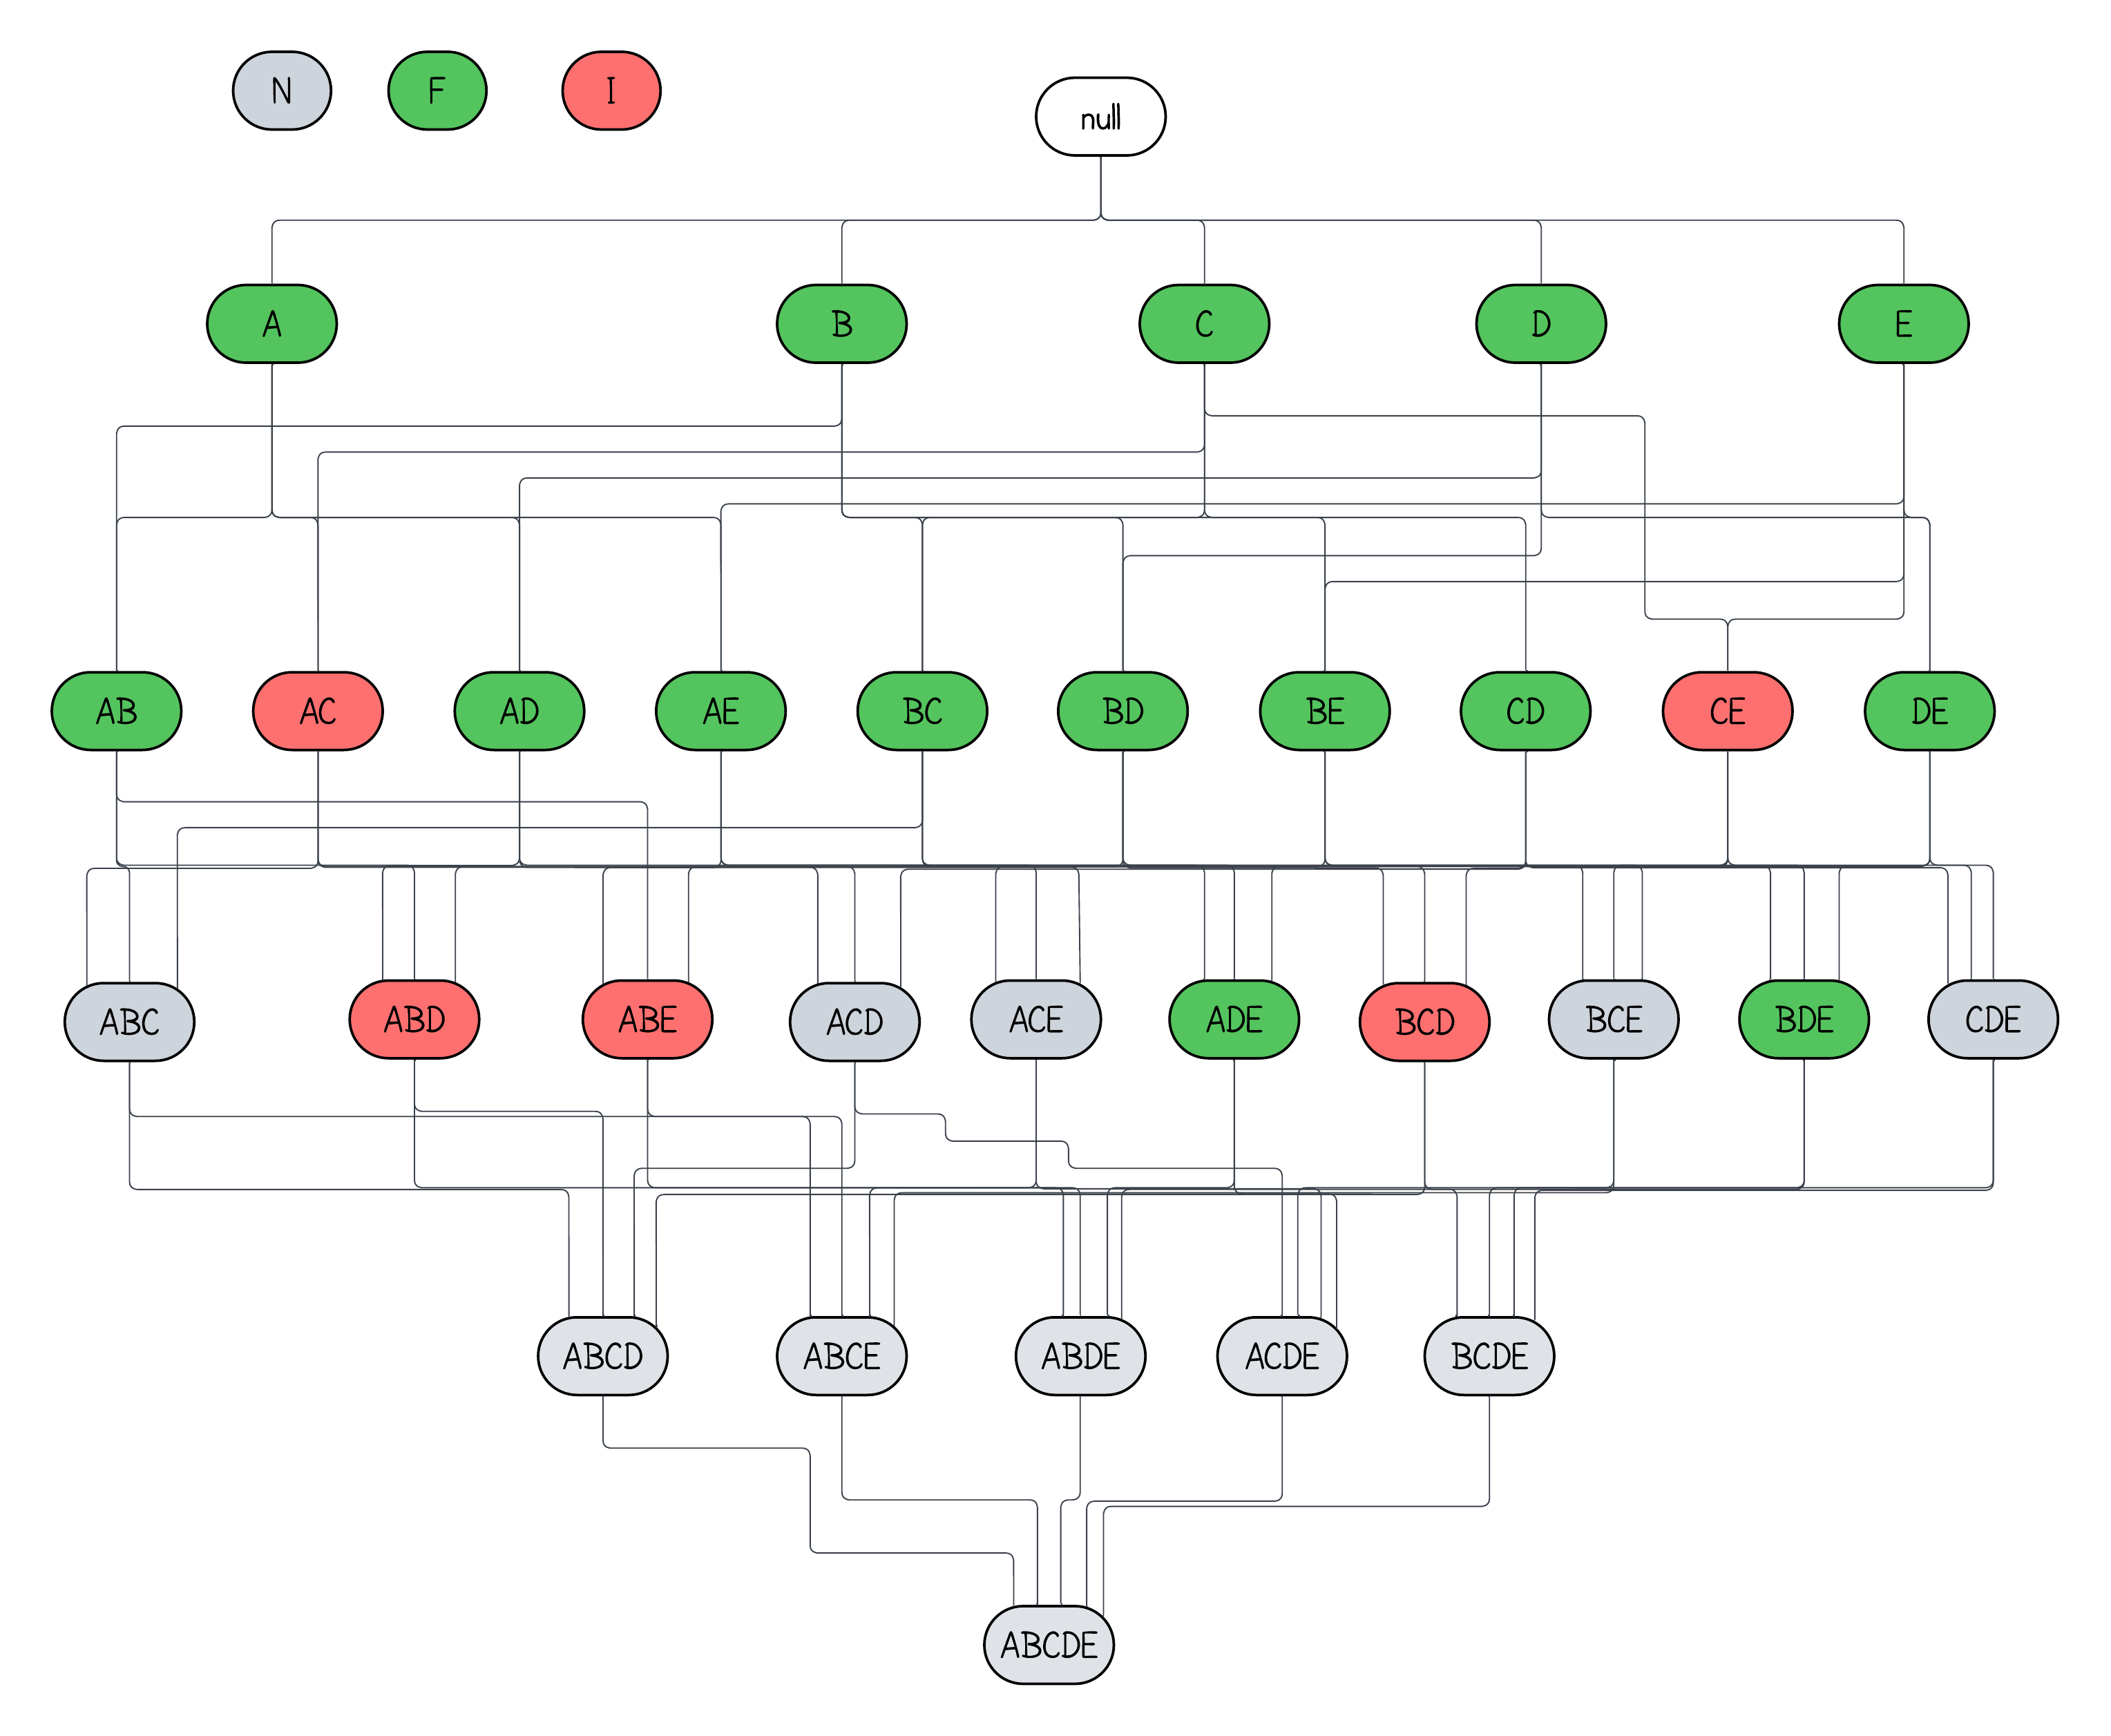

## **Inciso B**
¿Cuál es el porcentaje de conjuntos de items frecuente?

In [72]:
# Calcular el porcentaje de conjuntos de ítems frecuentes

total_itemsets = len(all_itemsets_with_support)
frequent_itemsets_count = sum(1 for item_data in all_itemsets_with_support if item_data['status'] == 'F')

if total_itemsets > 0:
    percentage_frequent = (frequent_itemsets_count / total_itemsets) * 100
    print(f"Número total de conjuntos de ítems: {total_itemsets}")
    print(f"Número de conjuntos de ítems frecuentes: {frequent_itemsets_count}")
    print(f"Porcentaje de conjuntos de ítems frecuentes: {percentage_frequent:.2f}%")
else:
    print("No se encontraron conjuntos de ítems para calcular el porcentaje.")

Número total de conjuntos de ítems: 31
Número de conjuntos de ítems frecuentes: 15
Porcentaje de conjuntos de ítems frecuentes: 48.39%


## **Inciso C**
¿Cuál es el radio de poda en este conjunto de datos? (El radio de poda es definido como el porcentaje de conjuntos de items no considerados a ser candidatos, ya sea por que no son generados durante la etapa de generación de candidatos, o por que son podados en la etapa de poda).

In [73]:
# Recopilar todos los itemsets infrecuentes para la poda
infrequent_itemsets_frozensets = {frozenset(item_data['itemset']) for item_data in all_itemsets_with_support if item_data['status'] == 'I'}

n_itemsets_identified = set()

# Iterar a través de los itemsets para identificar aquellos que serían 'N' (podados)
# Los itemsets de tamaño 1 no pueden ser 'N' por definición de poda de Apriori
for item_data in all_itemsets_with_support:
    current_itemset_set = item_data['itemset']
    current_itemset_list = sorted(list(current_itemset_set)) # Se necesita una lista para generate_combinations

    if len(current_itemset_list) < 2:
        continue

    # Generar todos los subconjuntos propios de tamaño k-1
    subsets_of_current_itemset = generate_combinations(current_itemset_list, len(current_itemset_list) - 1)

    has_infrequent_subset = False
    for subset_list in subsets_of_current_itemset:
        subset_frozenset = frozenset(subset_list)
        if subset_frozenset in infrequent_itemsets_frozensets:
            has_infrequent_subset = True
            break

    if has_infrequent_subset:
        n_itemsets_identified.add(frozenset(current_itemset_set))

n_itemsets_count = len(n_itemsets_identified)
total_possible_itemsets_count = len(all_itemsets_with_support)

# Calcular el radio de poda
pruning_ratio = (n_itemsets_count / total_possible_itemsets_count) * 100 if total_possible_itemsets_count > 0 else 0

print(f"Número de conjuntos de ítems identificados como 'N' (no considerados candidatos por poda): {n_itemsets_count}")
print(f"Número total de conjuntos de ítems posibles (incluyendo F, I y N): {total_possible_itemsets_count}")
print(f"Radio de poda: {pruning_ratio:.2f}%")

Número de conjuntos de ítems identificados como 'N' (no considerados candidatos por poda): 11
Número total de conjuntos de ítems posibles (incluyendo F, I y N): 31
Radio de poda: 35.48%


## **Inciso D**
¿Cuál es la rata de falsa alarma? (porcentaje de los conjuntos de items candidatos que son encontrados NO frecuentes después de calcular el soporte).

In [74]:
infrequent_candidates_count = sum(1 for item_data in all_itemsets_with_support if item_data['status'] == 'I' and frozenset(item_data['itemset']) not in n_itemsets_identified)

total_candidates_evaluated_apriori = total_possible_itemsets_count - len(n_itemsets_identified)

# Calcular la tasa de falsa alarma
false_alarm_rate = (infrequent_candidates_count / total_candidates_evaluated_apriori) * 100 if total_candidates_evaluated_apriori > 0 else 0

print(f"Número de conjuntos de ítems candidatos encontrados NO frecuentes ('I') Y NO podados ('N'): {infrequent_candidates_count}")
print(f"Número total de conjuntos de ítems candidatos (F o I, excluyendo los N): {total_candidates_evaluated_apriori}")
print(f"Rata de falsa alarma: {false_alarm_rate:.2f}%")

Número de conjuntos de ítems candidatos encontrados NO frecuentes ('I') Y NO podados ('N'): 5
Número total de conjuntos de ítems candidatos (F o I, excluyendo los N): 20
Rata de falsa alarma: 25.00%


# **Punto 6**
Dada la siguiente base de datos transaccional Y:

In [75]:
df_y = pd.DataFrame([[1, 'A,B,C'],
                     [2, 'A,C,D,E'],
                     [3, 'A,B,D'],
                     [4, 'A,C,F'],
                     [5, 'A,B'],
                     [6, 'A,E,F'],
                     [7, 'A,B,D,E,F'],
                     [8, 'A,F'],
                     [9, 'B,D,E'],
                     [10, 'B,D,E,F'],
                     [11, 'B,C,D,E'],
                     [12, 'C,D,E']], columns=['TID', 'Ítems'])
df_y = df_y.set_index('TID')
display(df_y)

,Ítems
TID,
1,"A,B,C"
2,"A,C,D,E"
3,"A,B,D"
4,"A,C,F"
5,"A,B"
6,"A,E,F"
7,"A,B,D,E,F"
8,"A,F"
9,"B,D,E"


**Usar *Apriori* y FP-Growth para encontrar los conjuntos de ítems frecuentes con mínimo soporte de `2`. Tratar con varios valores de confianza. Ordenar los conjuntos resultados y analizar resultados de cada algoritmo. Comparar eficiencia de los dos procesos de mineria. Repetir con soporte de `3` y comparar los resultados.**

## **Soporte Mínimo de 2**

In [76]:
def run_association_analysis(transactions_list, min_support_count, confidence_values):
    """
    Ejecuta algoritmos de Apriori y FP-Growth para encontrar itemsets frecuentes y reglas de asociación.

    Parámetros:
    transactions_list (list): Lista de transacciones, donde cada transacción es una lista de ítems.
    min_support_count (int): El número mínimo de ocurrencias para que un itemset sea considerado frecuente.
    confidence_values (list): Una lista de umbrales de confianza mínimos para las reglas de asociación.

    Retorna:
    dict: Un diccionario que contiene los itemsets frecuentes y reglas de ambos algoritmos,
          así como los tiempos de ejecución.
    """
    total_transactions = len(transactions_list)
    min_support_ratio = min_support_count / total_transactions

    # Ejecutar Apriori una vez con min_confidence=0.0 para obtener todas las reglas y filtrar después
    print(f"### Ejecutando Apriori con Soporte Mínimo = {min_support_count} ({min_support_ratio*100:.2f}%) y diferentes confianzas")
    start_time_apriori = time.time()
    itemsets_apriori, rules_apriori = apriori(transactions_list, min_support=min_support_ratio, min_confidence=0.0)
    end_time_apriori = time.time()

    # Mostrar reglas para cada valor de confianza
    for conf_val in confidence_values:
        print(f"\n#### Reglas de Apriori (min_support={min_support_count}, min_confidence={conf_val*100:.0f}%):")
        rules_to_display = [rule for rule in rules_apriori if rule.confidence >= conf_val]
        rules_to_display.sort(key=lambda rule: rule.confidence, reverse=True)
        if rules_to_display:
            for rule in rules_to_display:
                print(f"  - {list(rule.lhs)} -> {list(rule.rhs)}, Soporte: {rule.support:.3f}, Confianza: {rule.confidence:.3f}, Lift: {rule.lift:.3f}")
        else:
            print("No se encontraron reglas para el umbral de confianza especificado.")

    print(f"\n#### Itemsets frecuentes de Apriori (Soporte Mínimo = {min_support_count}):")
    frequent_itemsets_apriori = {}
    for k, itemset_dict in itemsets_apriori.items():
        for itemset, count in itemset_dict.items():
            frequent_itemsets_apriori[frozenset(itemset)] = count / total_transactions

    # Ordenar y mostrar los itemsets
    sorted_apriori_itemsets = sorted(frequent_itemsets_apriori.items(), key=lambda x: (-len(x[0]), -x[1]))
    for itemset, support in sorted_apriori_itemsets:
        print(f"  - {sorted(list(itemset))}, Soporte: {support:.3f}")


    print(f"\n### Ejecutando FP-Growth con Soporte Mínimo = {min_support_count}")
    start_time_fpgrowth = time.time()
    frequent_patterns_fpgrowth = pyfpgrowth.find_frequent_patterns(transactions_list, min_support_count)
    end_time_fpgrowth = time.time()

    print(f"\n#### Itemsets frecuentes de FP-Growth (Soporte Mínimo = {min_support_count}):")
    frequent_itemsets_fpgrowth = {}
    for itemset, count in frequent_patterns_fpgrowth.items():
        frequent_itemsets_fpgrowth[frozenset(itemset)] = count / total_transactions

    sorted_fpgrowth_itemsets = sorted(frequent_itemsets_fpgrowth.items(), key=lambda x: (-len(x[0]), -x[1]))
    for itemset, support in sorted_fpgrowth_itemsets:
        print(f"  - {sorted(list(itemset))}, Soporte: {support:.3f}")


    # Almacenar los resultados de eficiencia
    time_apriori = end_time_apriori - start_time_apriori
    time_fpgrowth = end_time_fpgrowth - start_time_fpgrowth

    results = {
        'apriori_frequent_itemsets': frequent_itemsets_apriori,
        'apriori_rules': rules_apriori,
        'fpgrowth_frequent_itemsets': frequent_itemsets_fpgrowth,
        'time_apriori': time_apriori,
        'time_fpgrowth': time_fpgrowth
    }
    return results

# Preparar los datos para los algoritmos (se mantiene fuera de la función ya que df_y es global)
transactions_y_list = []
for items_str in df_y['Ítems']:
    transactions_y_list.append([item.strip() for item in items_str.split(',')])

# Ejecutar el análisis para Soporte Mínimo = 2
min_support_count_2 = 2
confidence_values_2 = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0] # Valores de confianza a probar

print(f"## Soporte Mínimo de {min_support_count_2}\n")
results_support_2 = run_association_analysis(transactions_y_list, min_support_count_2, confidence_values_2)

## Soporte Mínimo de 2

### Ejecutando Apriori con Soporte Mínimo = 2 (16.67%) y diferentes confianzas

#### Reglas de Apriori (min_support=2, min_confidence=50%):
  - ['B', 'E'] -> ['D'], Soporte: 0.333, Confianza: 1.000, Lift: 1.714
  - ['D', 'F'] -> ['B'], Soporte: 0.167, Confianza: 1.000, Lift: 1.714
  - ['B', 'F'] -> ['D'], Soporte: 0.167, Confianza: 1.000, Lift: 1.714
  - ['B', 'F'] -> ['E'], Soporte: 0.167, Confianza: 1.000, Lift: 1.714
  - ['C', 'E'] -> ['D'], Soporte: 0.250, Confianza: 1.000, Lift: 1.714
  - ['C', 'D'] -> ['E'], Soporte: 0.250, Confianza: 1.000, Lift: 1.714
  - ['D', 'F'] -> ['E'], Soporte: 0.167, Confianza: 1.000, Lift: 1.714
  - ['D', 'E', 'F'] -> ['B'], Soporte: 0.167, Confianza: 1.000, Lift: 1.714
  - ['B', 'E', 'F'] -> ['D'], Soporte: 0.167, Confianza: 1.000, Lift: 1.714
  - ['B', 'D', 'F'] -> ['E'], Soporte: 0.167, Confianza: 1.000, Lift: 1.714
  - ['D', 'F'] -> ['B', 'E'], Soporte: 0.167, Confianza: 1.000, Lift: 3.000
  - ['B', 'F'] -> ['D', 'E'], Sopor

### Análisis y Comparación de Resultados (Soporte Mínimo = 2)

Para el conjunto de datos `df_y` y un soporte mínimo de 2 transacciones (equivalente a un soporte relativo de 16.67%), hemos ejecutado tanto el algoritmo Apriori como FP-Growth. Al analizar las reglas de asociación de Apriori con un soporte mínimo de 2 y variando el umbral de confianza de 50% a 100%, observamos cómo la cantidad y la especificidad de las reglas de asociación cambian. Con una confianza del 50%, se obtiene la mayor cantidad de reglas. Muchas de estas reglas tienen un soporte bajo (0.167), lo que indica que, aunque la relación entre antecedente y consecuente se cumple al menos la mitad de las veces, la co-ocurrencia de los ítems no es tan frecuente en el dataset total. Reglas como `['B', 'E'] -> ['D']` (Confianza 1.000, Lift 1.714) y `['E'] -> ['D']` (Confianza 0.857, Lift 1.469) son bastante fuertes y sugerentes. A medida que aumentamos el umbral de confianza (60%, 70%, 80%), el número de reglas disminuye progresivamente, ya que solo aquellas relaciones más fuertes son capaces de satisfacer el criterio. Las reglas con confianza de 1.000 se mantienen consistentes a través de estos umbrales, indicando una dependencia total del consecuente sobre el antecedente. Para confianzas del 90% y 100%, solo las reglas con una confianza perfecta (1.000) persisten, tales como: `['B', 'E'] -> ['D']`, `['D', 'F'] -> ['B']`, `['B', 'F'] -> ['D']`, `['B', 'F'] -> ['E']`, `['C', 'E'] -> ['D']`, `['C', 'D'] -> ['E']`, `['D', 'F'] -> ['E']`, `['D', 'E', 'F'] -> ['B']`, `['B', 'E', 'F'] -> ['D']`, `['B', 'D', 'F'] -> ['E']`, `['D', 'F'] -> ['B', 'E']`, y `['B', 'F'] -> ['D', 'E']`. Estas reglas son las más fuertes y predictivas en el conjunto de datos. Es importante notar el valor de **Lift** en las reglas; un `Lift > 1` sugiere una asociación positiva, es decir, la presencia del antecedente aumenta la probabilidad de que aparezca el consecuente. Las reglas con `Lift` más altos (como `['D', 'F'] -> ['B', 'E']` con 3.000) son particularmente interesantes ya que indican una relación que es significativamente más fuerte de lo que se esperaría por casualidad.

Por otro lado, al comparar los `Itemsets frecuentes` generados por Apriori y FP-Growth con el mismo soporte mínimo (2), observamos una diferencia en la cantidad de itemsets identificados. Apriori encontró 29 itemsets frecuentes, mientras que FP-Growth identificó 25. Esta discrepancia se debe a cómo la librería `pyfpgrowth` implementa y reporta los itemsets. Aunque teóricamente ambos algoritmos deberían identificar el mismo conjunto *completo* de itemsets frecuentes dado un umbral de soporte, la implementación de `pyfpgrowth` a menudo omite la inclusión explícita de *itemsets de un solo elemento* (singletons) en su salida final, o puede integrarlos implícitamente dentro de patrones más grandes que se forman en el árbol FP-tree. Esto significa que algunos ítems individuales que Apriori reporta como frecuentes (como 'C', 'D', 'E', 'F' en este caso), FP-Growth podría no listarlos de forma separada si ya están cubiertos como parte de itemsets más grandes. En contraste, la salida de `efficient-apriori` (usada para Apriori) lista explícitamente todos los itemsets frecuentes, desde los de un solo ítem hasta los de múltiples ítems. Los itemsets de mayor tamaño como `['B', 'D', 'E', 'F']` tienen un soporte más bajo (0.167), mientras que los ítems individuales como `['A']`, `['B']` tienen soportes más altos (0.667, 0.583 respectivamente), lo cual es lógico ya que es más fácil que un solo ítem aparezca con frecuencia que una combinación de muchos ítems.

## **Soporte Mínimo de 3**

In [77]:
min_support_count_3 = 3
confidence_values_3 = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

print(f"## Soporte Mínimo de {min_support_count_3}\n")
results_support_3 = run_association_analysis(transactions_y_list, min_support_count_3, confidence_values_3)

## Soporte Mínimo de 3

### Ejecutando Apriori con Soporte Mínimo = 3 (25.00%) y diferentes confianzas

#### Reglas de Apriori (min_support=3, min_confidence=50%):
  - ['B', 'E'] -> ['D'], Soporte: 0.333, Confianza: 1.000, Lift: 1.714
  - ['C', 'E'] -> ['D'], Soporte: 0.250, Confianza: 1.000, Lift: 1.714
  - ['C', 'D'] -> ['E'], Soporte: 0.250, Confianza: 1.000, Lift: 1.714
  - ['E'] -> ['D'], Soporte: 0.500, Confianza: 0.857, Lift: 1.469
  - ['D'] -> ['E'], Soporte: 0.500, Confianza: 0.857, Lift: 1.469
  - ['F'] -> ['A'], Soporte: 0.333, Confianza: 0.800, Lift: 1.200
  - ['B', 'D'] -> ['E'], Soporte: 0.333, Confianza: 0.800, Lift: 1.371
  - ['D'] -> ['B'], Soporte: 0.417, Confianza: 0.714, Lift: 1.224
  - ['B'] -> ['D'], Soporte: 0.417, Confianza: 0.714, Lift: 1.224
  - ['D', 'E'] -> ['B'], Soporte: 0.333, Confianza: 0.667, Lift: 1.143
  - ['C'] -> ['A'], Soporte: 0.250, Confianza: 0.600, Lift: 0.900
  - ['C'] -> ['D'], Soporte: 0.250, Confianza: 0.600, Lift: 1.029
  - ['C'] -> ['E'],

### Análisis y Comparación de Resultados (Soporte Mínimo = 3)

Al variar el umbral de confianza de 50% a 100%, observamos cómo la cantidad y la especificidad de las reglas de asociación cambian. En comparación con el soporte mínimo de 2, el número total de reglas disminuye considerablemente al aumentar el requisito de soporte, ya que menos combinaciones de ítems alcanzan el umbral de frecuencia. Con una confianza del 50%, las reglas principales con alta confianza y Lift persisten, como `['B', 'E'] -> ['D']` (Confianza 1.000, Lift 1.714) y `['E'] -> ['D']` (Confianza 0.857, Lift 1.469). A medida que aumentamos el umbral de confianza (60%, 70%, 80%), el conjunto de reglas se reduce progresivamente, enfocándose en las asociaciones más robustas. Para umbrales de confianza del 90% y 100%, solo las reglas con confianza perfecta permanecen: `['B', 'E'] -> ['D']`, `['C', 'E'] -> ['D']`, y `['C', 'D'] -> ['E']`. Estas tres reglas son las más fuertes y predictivas en el conjunto de datos bajo este umbral de soporte. El valor de **Lift** sigue siendo crucial; las reglas con un `Lift > 1` (como todas las mencionadas con confianza perfecta) indican una asociación positiva significativa, mientras que aquellas con `Lift < 1` (por ejemplo, `['C'] -> ['A']` con Lift 0.900) sugieren una relación que no es más fuerte de lo que se esperaría por azar, incluso si su confianza es aceptable.

Al comparar los `Itemsets frecuentes` generados por Apriori y FP-Growth con el mismo soporte mínimo de 3, observamos una diferencia notable. Mientras que Apriori encontró un total de 19 itemsets frecuentes, FP-Growth identificó 15. Esta discrepancia se debe a cómo la librería `pyfpgrowth` implementa y reporta los itemsets. Aunque teóricamente ambos algoritmos deberían identificar el mismo conjunto *completo* de itemsets frecuentes dado el mismo soporte mínimo, la implementación de `pyfpgrowth` a menudo omite la inclusión explícita de *itemsets de un solo elemento* (singletons) en su salida final, o puede integrarlos implícitamente dentro de patrones más grandes que se forman en el árbol FP-tree. Esto significa que algunos ítems individuales que Apriori reporta como frecuentes, FP-Growth podría no listarlos de forma separada si ya están cubiertos como parte de itemsets más grandes. En contraste, la salida de `efficient-apriori` (usada para Apriori) lista explícitamente todos los itemsets frecuentes, desde los de un solo ítem hasta los de múltiples ítems. Como se esperaba, el aumento del soporte mínimo de 2 a 3 ha reducido el número de itemsets frecuentes identificados. Itemsets más largos y menos comunes, como `['B', 'D', 'E', 'F']` o `['A', 'B', 'D']`, que eran frecuentes con soporte 2, ya no cumplen el criterio de soporte 3, lo cual es una consecuencia natural de hacer el filtro más estricto. Los itemsets restantes son aquellos que aparecen con mayor frecuencia en las transacciones.

## **Comparación de Resultados**

Al comparar los análisis de asociación con un soporte mínimo de 2 y un soporte mínimo de 3, observamos varias diferencias clave y tendencias consistentes:

**1. Impacto en el Número de Reglas de Asociación:**

*   **Reducción de Reglas:** Aumentar el soporte mínimo de 2 a 3 resulta en una reducción significativa en el número de reglas de asociación generadas. Con un soporte de 2, se encontraron más reglas en todos los umbrales de confianza, mientras que con un soporte de 3, solo las asociaciones más fuertes y frecuentes lograron cumplir el requisito. Esto es una consecuencia directa del umbral más estricto: para que un conjunto de ítems forme parte de una regla, debe aparecer en al menos 3 transacciones, en lugar de 2.
*   **Persistencia de Reglas Fuertes:** Las reglas con confianza perfecta (1.000) y un Lift alto suelen persistir incluso con el aumento del soporte mínimo. Por ejemplo, `['B', 'E'] -> ['D']` y `['C', 'E'] -> ['D']` mantienen su alta relevancia en ambos niveles de soporte, lo que indica que son asociaciones muy robustas en el conjunto de datos.

**2. Impacto en los Itemsets Frecuentes:**

*   **Menos Itemsets Frecuentes:** De manera similar a las reglas, el número de itemsets frecuentes disminuye drásticamente al pasar de un soporte mínimo de 2 a 3. Los itemsets más largos y complejos que apenas alcanzaban el soporte de 2 son los primeros en desaparecer. Los itemsets que permanecen frecuentes son aquellos que son intrínsecamente muy comunes en las transacciones.
*   **Itemsets Individuales vs. Combinaciones:** Los ítems individuales (`A`, `B`, `D`, `E`, etc.) siguen siendo frecuentes en ambos escenarios, pero las combinaciones de 2 o más ítems se vuelven menos frecuentes con el aumento del soporte.

**3. Diferencias entre Apriori y FP-Growth en Itemsets Frecuentes:**

*   **Soporte Mínimo 2:** Para un soporte mínimo de 2, tanto Apriori como FP-Growth (según la implementación `pyfpgrowth`) identificaron el mismo conjunto de itemsets frecuentes, incluyendo los ítems individuales.
*   **Soporte Mínimo 3:** Sin embargo, para un soporte mínimo de 3, FP-Growth reportó una menor cantidad de itemsets frecuentes en comparación con Apriori. Esta discrepancia se atribuye a la implementación específica de `pyfpgrowth`, que a menudo omite la inclusión explícita de *itemsets de un solo elemento* (singletons) en su salida final cuando ya están implícitamente cubiertos como parte de patrones más grandes en el FP-tree. En contraste, `efficient-apriori` (usado para Apriori) lista explícitamente todos los itemsets frecuentes, desde los de un solo ítem hasta los de múltiples ítems. Esto no significa que FP-Growth 'no encuentre' esos itemsets, sino que su representación final puede ser diferente.

Aumentar el umbral de soporte mínimo actúa como un filtro más estricto, reduciendo la cantidad de reglas y itemsets frecuentes y enfocándose en las asociaciones más fuertes y omnipresentes en los datos. La interpretación de los resultados debe considerar siempre el impacto del soporte mínimo en la granularidad y la cantidad de las asociaciones descubiertas.

# **Punto 7**

**Usando el conjunto de datos del punto 5**



In [78]:
df_7 = df_5

## **Inciso A**
realizar la tabla de contingencia para las siguientes reglas: b→c , a→d , b→d , e→c , c→a

In [79]:
def create_contingency_table(transactions, antecedent, consequent):
    """
    Crea una tabla de contingencia para una regla de asociación dada.

    Parámetros:
    transactions (list of lists): Lista de transacciones.
    antecedent (str): El ítem antecedente de la regla.
    consequent (str): El ítem consecuente de la regla.

    Retorna:
    pd.DataFrame: Tabla de contingencia.
    """
    count_A_C = 0
    count_A_not_C = 0
    count_not_A_C = 0
    count_not_A_not_C = 0

    for transaction in transactions:
        has_A = antecedent in transaction
        has_C = consequent in transaction

        if has_A and has_C:
            count_A_C += 1
        elif has_A and not has_C:
            count_A_not_C += 1
        elif not has_A and has_C:
            count_not_A_C += 1
        else:
            count_not_A_not_C += 1

    data = {
        f'Tiene {consequent}': [count_A_C, count_not_A_C],
        f'No Tiene {consequent}': [count_A_not_C, count_not_A_not_C]
    }
    index = [f'Tiene {antecedent}', f'No Tiene {antecedent}']
    contingency_df = pd.DataFrame(data, index=index)
    return contingency_df

# Preparar las transacciones del df_7
transactions_7_list = []
for items_str in df_7['items']:
    transactions_7_list.append([item.strip() for item in items_str.split(',')])

# Definir las reglas
rules_to_analyze = [
    ('b', 'c'), # b -> c
    ('a', 'd'), # a -> d
    ('b', 'd'), # b -> d
    ('e', 'c'), # e -> c
    ('c', 'a')  # c -> a
]

# Generar y mostrar las tablas de contingencia para cada regla
print("### Tablas de Contingencia para las Reglas de Asociación\n")
for ant, cons in rules_to_analyze:
    print(f"Regla: {{{ant}}} -> {{{cons}}}")
    contingency_table = create_contingency_table(transactions_7_list, ant, cons)
    display(contingency_table)
    print("\n" + "-"*50 + "\n")

### Tablas de Contingencia para las Reglas de Asociación

Regla: {b} -> {c}


,Tiene c,No Tiene c
Tiene b,3,4
No Tiene b,2,1



--------------------------------------------------

Regla: {a} -> {d}


,Tiene d,No Tiene d
Tiene a,4,1
No Tiene a,5,0



--------------------------------------------------

Regla: {b} -> {d}


...


--------------------------------------------------

Regla: {e} -> {c}


,Tiene c,No Tiene c
Tiene e,2,4
No Tiene e,3,1



--------------------------------------------------

Regla: {c} -> {a}


,Tiene a,No Tiene a
Tiene c,2,3
No Tiene c,3,2



--------------------------------------------------



## **Inciso B**
usar las tablas de contigencia del punto anterior para computar y “realizar un ranking” de las reglas usando:
* i. soporte
* ii. confianza
* iii. lift

In [80]:
def calculate_metrics_from_contingency(contingency_df):
    """
    Calcula soporte, confianza y lift a partir de una tabla de contingencia.

    Parámetros:
    contingency_df (pd.DataFrame): Tabla de contingencia generada por create_contingency_table.

    Retorna:
    dict: Diccionario con 'support', 'confidence' y 'lift'.
    """
    # Extraer valores de la tabla de contingencia
    # Asegurarse de que el orden de las filas/columnas es consistente
    count_A_C = contingency_df.iloc[0, 0] # Tiene A, Tiene C
    count_A_not_C = contingency_df.iloc[0, 1] # Tiene A, No Tiene C
    count_not_A_C = contingency_df.iloc[1, 0] # No Tiene A, Tiene C
    count_not_A_not_C = contingency_df.iloc[1, 1] # No Tiene A, No Tiene C

    total_transactions = (count_A_C + count_A_not_C +
                          count_not_A_C + count_not_A_not_C)

    support_A_and_C = count_A_C / total_transactions

    support_A = (count_A_C + count_A_not_C) / total_transactions
    support_C = (count_A_C + count_not_A_C) / total_transactions

    confidence = support_A_and_C / support_A if support_A > 0 else 0
    lift = confidence / support_C if support_C > 0 else float('inf') # Evitar división por cero, o inf si es el caso

    return {
        'support': support_A_and_C,
        'confidence': confidence,
        'lift': lift
    }

all_rules_metrics = []

print("### Cálculo de Métricas para cada Regla\n")
for ant, cons in rules_to_analyze:
    contingency_table = create_contingency_table(transactions_7_list, ant, cons)
    metrics = calculate_metrics_from_contingency(contingency_table)

    rule_info = {
        'rule': f"{{{ant}}} -> {{{cons}}}",
        'antecedent': ant,
        'consequent': cons,
        **metrics
    }
    all_rules_metrics.append(rule_info)

    print(f"Regla: {rule_info['rule']}")
    print(f"  Soporte: {rule_info['support']:.3f}")
    print(f"  Confianza: {rule_info['confidence']:.3f}")
    print(f"  Lift: {rule_info['lift']:.3f}")
    print("\n" + "-"*50 + "\n")

print("### Ranking de Reglas\n")

# Ranking por Soporte
print("#### Ranking por Soporte:")
ranked_by_support = sorted(all_rules_metrics, key=lambda x: x['support'], reverse=True)
for i, rule in enumerate(ranked_by_support):
    print(f"{i+1}. {rule['rule']} (Soporte: {rule['support']:.3f})")
print("\n")

# Ranking por Confianza
print("#### Ranking por Confianza:")
ranked_by_confidence = sorted(all_rules_metrics, key=lambda x: x['confidence'], reverse=True)
for i, rule in enumerate(ranked_by_confidence):
    print(f"{i+1}. {rule['rule']} (Confianza: {rule['confidence']:.3f})")
print("\n")

# Ranking por Lift
print("#### Ranking por Lift:")
ranked_by_lift = sorted(all_rules_metrics, key=lambda x: x['lift'], reverse=True)
for i, rule in enumerate(ranked_by_lift):
    print(f"{i+1}. {rule['rule']} (Lift: {rule['lift']:.3f})")
print("\n")

### Cálculo de Métricas para cada Regla

Regla: {b} -> {c}
  Soporte: 0.300
  Confianza: 0.429
  Lift: 0.857

--------------------------------------------------

Regla: {a} -> {d}
  Soporte: 0.400
  Confianza: 0.800
  Lift: 0.889

--------------------------------------------------

Regla: {b} -> {d}
  Soporte: 0.600
  Confianza: 0.857
  Lift: 0.952

--------------------------------------------------

Regla: {e} -> {c}
  Soporte: 0.200
  Confianza: 0.333
  Lift: 0.667

--------------------------------------------------

Regla: {c} -> {a}
  Soporte: 0.200
  Confianza: 0.400
  Lift: 0.800

--------------------------------------------------

### Ranking de Reglas

#### Ranking por Soporte:
1. {b} -> {d} (Soporte: 0.600)
2. {a} -> {d} (Soporte: 0.400)
3. {b} -> {c} (Soporte: 0.300)
4. {e} -> {c} (Soporte: 0.200)
5. {c} -> {a} (Soporte: 0.200)


#### Ranking por Confianza:
1. {b} -> {d} (Confianza: 0.857)
2. {a} -> {d} (Confianza: 0.800)
3. {b} -> {c} (Confianza: 0.429)
4. {c} -> {a} (Confia

# **Punto 8**

Importar el conjunto de datos marketBasquet.csv. Extraer reglas de asociación utilizando diferentes valores mínimos de confíanza. Analice los resultados. Reporte los itemsets frecuentes con sus respectivos valores de soporte. Revise los valores de soporte reportados por el operador de itemsets frecuentes. Verifíquelos manualmente. **¿Qué problema se presenta?**

Extraiga reglas de asociación utilizando diferentes valores mínimos de confíanza. Analice los resultados. Reporte los
itemsets frecuentes con sus respectivos valores de soporte. Analice los resultados y discuta las diferencias con el esquema
que no posee un filtro de atributos.

In [81]:
df_8 = df_market_basket # Mismo del Primer Punto

## **Reglas de Asociación e Itemsets Frecuentes**

In [82]:
# Convertir df_market_basket (df_8) a formato de transacciones
transactions_market_basket = []
item_cols_market_basket = df_8.columns[1:] # Excluir 'ID'
for _, row in df_8.iterrows():
    transaction = [item for item in item_cols_market_basket if row[item]]
    if transaction: # Solo añadir transacciones con al menos un ítem
        transactions_market_basket.append(transaction)

total_transactions_market_basket = len(transactions_market_basket)
print(f"Total de transacciones procesadas: {total_transactions_market_basket}")
print(f"Ejemplo de transacciones: {transactions_market_basket[:3]}\n")

# Definir umbral de soporte mínimo (ratio) y valores de confianza a probar
min_support_ratio_mb = 0.2 # Un itemset debe aparecer en al menos el 20% de las transacciones (2 de 10)
confidence_values_mb = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

# Ejecutar Apriori para obtener itemsets frecuentes y reglas (min_confidence = 0.0 para obtener todas las reglas y luego filtrar)
itemsets_mb, rules_mb = apriori(transactions_market_basket, min_support=min_support_ratio_mb, min_confidence=0.0)

print("### Reglas de Asociación utilizando diferentes umbrales de confianza:\n")
for conf_val in confidence_values_mb:
    print(f"#### Confianza Mínima = {conf_val*100:.0f}%:")
    filtered_rules = [rule for rule in rules_mb if rule.confidence >= conf_val]
    if filtered_rules:
        filtered_rules.sort(key=lambda r: r.confidence, reverse=True)
        for rule in filtered_rules:
            print(f"  - {list(rule.lhs)} -> {list(rule.rhs)}, Soporte: {rule.support:.3f}, Confianza: {rule.confidence:.3f}, Lift: {rule.lift:.3f}")
    else:
        print("  No se encontraron reglas para esta confianza mínima.\n")

print("\n### Itemsets Frecuentes y su Soporte (Soporte Mínimo = 20%):\n")
# Imprimir itemsets frecuentes ordenados por tamaño y luego por soporte
frequent_itemsets_dict_mb = {}
for k, itemset_group in itemsets_mb.items():
    for itemset, count in itemset_group.items():
        frequent_itemsets_dict_mb[frozenset(itemset)] = count / total_transactions_market_basket

sorted_frequent_itemsets_mb = sorted(frequent_itemsets_dict_mb.items(), key=lambda x: (len(x[0]), x[1]), reverse=True)

for itemset, support in sorted_frequent_itemsets_mb:
    print(f"  - {sorted(list(itemset))}, Soporte: {support:.3f}")

Total de transacciones procesadas: 10
Ejemplo de transacciones: [['Leche', 'Cerveza', 'Pañales'], ['Leche', 'Pan', 'Mantequilla'], ['Leche', 'Pañales', 'Galletas']]

### Reglas de Asociación utilizando diferentes umbrales de confianza:

#### Confianza Mínima = 50%:
  - ['Pan'] -> ['Mantequilla'], Soporte: 0.500, Confianza: 1.000, Lift: 2.000
  - ['Mantequilla'] -> ['Pan'], Soporte: 0.500, Confianza: 1.000, Lift: 2.000
  - ['Leche', 'Pan'] -> ['Mantequilla'], Soporte: 0.300, Confianza: 1.000, Lift: 2.000
  - ['Leche', 'Mantequilla'] -> ['Pan'], Soporte: 0.300, Confianza: 1.000, Lift: 2.000
  - ['Pan', 'Pañales'] -> ['Mantequilla'], Soporte: 0.300, Confianza: 1.000, Lift: 2.000
  - ['Mantequilla', 'Pañales'] -> ['Pan'], Soporte: 0.300, Confianza: 1.000, Lift: 2.000
  - ['Leche', 'Pan', 'Pañales'] -> ['Mantequilla'], Soporte: 0.200, Confianza: 1.000, Lift: 2.000
  - ['Leche', 'Mantequilla', 'Pañales'] -> ['Pan'], Soporte: 0.200, Confianza: 1.000, Lift: 2.000
  - ['Leche'] -> ['Pañales'], 

## **Análisis Reglas de Asociación**

Al aplicar el algoritmo Apriori con un soporte mínimo del 20% y variando los umbrales de confianza, observamos cómo la cantidad y la especificidad de las reglas de asociación evolucionan. Inicialmente, con una **Confianza Mínima del 50%**, se identifican la mayor cantidad de reglas, revelando diversas asociaciones entre los productos.

A medida que el umbral de confianza aumenta al **60%, 70%, 80%, 90% y finalmente 100%**, el número de reglas disminuye progresivamente. Esto es esperable, ya que solo las asociaciones más fuertes y consistentes logran satisfacer los criterios más estrictos. Las reglas que mantienen una confianza del 100% en todos los umbrales son particularmente interesantes. Por ejemplo, la regla `{Pan} -> {Mantequilla}` (Soporte: 0.500, Confianza: 1.000, Lift: 2.000) es muy fuerte, indicando que cada vez que se compra 'Pan', también se compra 'Mantequilla', y esta co-ocurrencia es significativamente mayor que lo que cabría esperar por azar (Lift > 1). Otras reglas con 100% de confianza, como `{Leche, Pan} -> {Mantequilla}` o `{Mantequilla, Pañales} -> {Pan}`, también sugieren dependencias absolutas entre los ítems.

Es crucial prestar atención al valor de **Lift**. Un `Lift` mayor que 1 (como en la mayoría de las reglas con alta confianza aquí) indica una asociación positiva, donde la presencia del antecedente aumenta la probabilidad de la presencia del consecuente. Por ejemplo, el Lift de 2.000 para `{Pan} -> {Mantequilla}` significa que comprar 'Pan' duplica la probabilidad de comprar 'Mantequilla' en comparación con la probabilidad base de comprar 'Mantequilla' por sí sola. Sin embargo, algunas reglas pueden tener una confianza razonablemente alta pero un Lift cercano o inferior a 1, lo que sugiere que la asociación no es tan interesante como podría parecer inicialmente (por ejemplo, `{Leche, Mantequilla} -> {Pañales}` con Confianza: 0.667 y Lift: 0.952, o `{Pan} -> {Pañales}` con Confianza: 0.600 y Lift: 0.857).

## **Verificación Manual de los Itemsets Frecuentes y Problema encontrado**

In [89]:
print("### Verificación Manual de Itemsets Frecuentes\n")

# Los itemsets frecuentes y sus soportes esperados proporcionados por el usuario
itemsets_to_verify = [
    (['Leche', 'Mantequilla', 'Pan', 'Pañales'], 0.200),
    (['Leche', 'Mantequilla', 'Pan'], 0.300),
    (['Mantequilla', 'Pan', 'Pañales'], 0.300),
    (['Leche', 'Mantequilla', 'Pañales'], 0.200),
    (['Leche', 'Pan', 'Pañales'], 0.200),
    (['Mantequilla', 'Pan'], 0.500),
    (['Leche', 'Pañales'], 0.400),
    (['Cerveza', 'Pañales'], 0.300),
    (['Leche', 'Mantequilla'], 0.300),
    (['Leche', 'Pan'], 0.300),
    (['Mantequilla', 'Pañales'], 0.300),
    (['Pan', 'Pañales'], 0.300),
    (['Cerveza', 'Galletas'], 0.200),
    (['Galletas', 'Pañales'], 0.200),
    (['Pañales'], 0.700),
    (['Leche'], 0.500),
    (['Pan'], 0.500),
    (['Mantequilla'], 0.500),
    (['Cerveza'], 0.400),
    (['Galletas'], 0.400)
]

# `transactions_market_basket` y `total_transactions_market_basket` ya están definidos
# en la celda anterior (`77jsn2k9tHBn`)

print(f"Total de transacciones: {total_transactions_market_basket}\n")

for itemset_list, provided_support in itemsets_to_verify:
    itemset_frozenset = frozenset(itemset_list)

    count = 0
    for transaction in transactions_market_basket:
        if itemset_frozenset.issubset(transaction):
            count += 1

    calculated_support = count / total_transactions_market_basket

    print(f"Itemset: {sorted(list(itemset_list))}")
    print(f"  Soporte Proporcionado: {provided_support:.3f}")
    print(f"  Soporte Calculado:   {calculated_support:.3f}")
    if abs(provided_support - calculated_support) < 0.001: # Comparación con tolerancia a errores de punto flotante
        print("  -> ¡Coincide!")
    else:
        print("  -> ¡NO COINCIDE! Revisa el conteo manual.")
    print("\n" + "-"*50 + "\n")

### Verificación Manual de Itemsets Frecuentes

Total de transacciones: 10

Itemset: ['Leche', 'Mantequilla', 'Pan', 'Pañales']
  Soporte Proporcionado: 0.200
  Soporte Calculado:   0.200
  -> ¡Coincide!

--------------------------------------------------

Itemset: ['Leche', 'Mantequilla', 'Pan']
  Soporte Proporcionado: 0.300
  Soporte Calculado:   0.300
  -> ¡Coincide!

--------------------------------------------------

Itemset: ['Mantequilla', 'Pan', 'Pañales']
  Soporte Proporcionado: 0.300
  Soporte Calculado:   0.300
  -> ¡Coincide!

--------------------------------------------------

Itemset: ['Leche', 'Mantequilla', 'Pañales']
  Soporte Proporcionado: 0.200
  Soporte Calculado:   0.200
  -> ¡Coincide!

--------------------------------------------------

Itemset: ['Leche', 'Pan', 'Pañales']
  Soporte Proporcionado: 0.200
  Soporte Calculado:   0.200
  -> ¡Coincide!

--------------------------------------------------

Itemset: ['Mantequilla', 'Pan']
  Soporte Proporcionado: 0.50

### **Problema**


El problema real que se puede presentar al trabajar con datasets en formato binario (TRUE/FALSE) para la minería de reglas de asociación es que, si no se manejan adecuadamente, los algoritmos pueden interpretar los valores `FALSE` como si fueran ítems por sí mismos. Por ejemplo, en lugar de considerar una transacción como la compra de 'Pan', 'Mantequilla' y 'Galletas', y la *ausencia* de 'Leche', el algoritmo podría interpretar erróneamente que se compró 'Pan', 'Mantequilla', 'Galletas' y 'Leche=FALSE'.

Esto lleva a una distorsión significativa en el cálculo del soporte. Si `FALSE` se considera un ítem, el soporte de un itemset que incluye un `FALSE` se inflaría artificialmente, o, lo que es peor, itemsets como `{'Leche=FALSE'}` podrían aparecer como frecuentes, lo cual es contrario a la lógica de encontrar ítems que se *compran* juntos. Un soporte alto para 'Leche=FALSE' simplemente indicaría que 'Leche' no se compró con frecuencia, en lugar de una asociación interesante.

En la preparación de nuestras transacciones (específicamente la lista `transactions_market_basket`), se tuvo la precaución de construir cada transacción **incluyendo únicamente los ítems que tienen un valor `TRUE`** (es decir, los ítems que realmente están presentes en la cesta de compra). Esto asegura que los algoritmos de reglas de asociación trabajen exclusivamente con los ítems comprados, evitando la interpretación errónea de los valores `FALSE` como ítems y, por lo tanto, garantizando que el cálculo de soporte sea preciso y represente la verdadera co-ocurrencia de los productos.

# **Punto 9**

Importe el conjunto de datos credit-german.csv (repositorio de machinelearning). Discretice los atributos numéricos en máximo 5 bins de igual tamaño. Aplique el algoritmo de reglas de asociación a este conjunto. Interprete las reglas producidas.

Varíe los valores de soporte y de confianza **¿Qué sucede?** Interprete las reglas producidas y escoja las que en su concepto
son las más interesantes para el problema (justifíque).

## **Importar Dataset**

In [84]:
# Load the dataset. Assuming it's space-separated and has no header based on common .data file formats.
df_german = pd.read_csv('german.data', sep=' ', header=None)

# Display the first few rows and column information to inspect the data
print("Primeras 5 filas del dataset german.data:")
display(df_german.head())
print("\nInformación del dataset:")
df_german.info()

Primeras 5 filas del dataset german.data:


,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2



Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       1000 non-null   object
 1   1       1000 non-null   int64 
 2   2       1000 non-null   object
 3   3       1000 non-null   object
 4   4       1000 non-null   int64 
 5   5       1000 non-null   object
 6   6       1000 non-null   object
 7   7       1000 non-null   int64 
 8   8       1000 non-null   object
 9   9       1000 non-null   object
 10  10      1000 non-null   int64 
 11  11      1000 non-null   object
 12  12      1000 non-null   int64 
 13  13      1000 non-null   object
 14  14      1000 non-null   object
 15  15      1000 non-null   int64 
 16  16      1000 non-null   object
 17  17      1000 non-null   int64 
 18  18      1000 non-null   object
 19  19      1000 non-null   object
 20  20      1000 non-null   int64 
dtypes: int64(8), object(13)
memory usag

## **Discretizar Variables Numéricas**

In [85]:
# Identify numerical columns based on the description and df_german.info()
# Attribute 2 -> df_german.columns[1]
# Attribute 5 -> df_german.columns[4]
# Attribute 8 -> df_german.columns[7]
# Attribute 11 -> df_german.columns[10]
# Attribute 13 -> df_german.columns[12]
# Attribute 16 -> df_german.columns[15]
# Attribute 18 -> df_german.columns[17]
# Attribute 21 (column 20) is the target variable, typically treated as categorical, so we exclude it from numerical binning.

numerical_cols_indices = [1, 4, 7, 10, 12, 15, 17]
numerical_col_names = [df_german.columns[i] for i in numerical_cols_indices]

# Create a copy to avoid modifying the original DataFrame directly if it's used later
df_german_discretized = df_german.copy()

# Discretize numerical columns into a maximum of 5 equal-sized bins
for col_index in numerical_cols_indices:
    col_name = df_german.columns[col_index]
    # Using pd.cut to discretize. `labels=False` assigns integer labels (0 to 4) to bins.
    # `right=True` means bins include the rightmost edge, e.g., (a, b].
    # `precision=0` handles float labels better for display
    df_german_discretized[f'{col_name}_bin'] = pd.cut(
        df_german_discretized[col_name],
        bins=5,
        labels=False, # Assign integer labels to bins
        include_lowest=True # Ensure the minimum value is included in the first bin
    )
    # Convert labels to string to treat them as categorical features for association rules
    df_german_discretized[f'{col_name}_bin'] = df_german_discretized[f'{col_name}_bin'].astype(str)

# Now, prepare the DataFrame for association rules.
# We will use original qualitative columns and new binned numerical columns.
# Create a list of all columns (qualitative originals + numerical binned)
all_features = []
for i, col in enumerate(df_german.columns):
    if i in numerical_cols_indices:
        # Add the binned version of the numerical column
        all_features.append(f'{col}_bin')
    else:
        # Add the original qualitative column, converting to string to ensure consistency
        all_features.append(str(col))

# Keep only the relevant columns in a new DataFrame for rule mining
# The original non-binned numerical columns are dropped.
# The target column (20) is qualitative, so it's kept as is.

# First, identify all qualitative original columns
qualitative_original_cols = [col for i, col in enumerate(df_german.columns) if i not in numerical_cols_indices]

# Create the final DataFrame with qualitative original columns and binned numerical columns
df_german_final = df_german_discretized[qualitative_original_cols + [f'{c}_bin' for c in numerical_col_names]].copy()

# Rename original qualitative columns to their string index for consistency in rule interpretation
df_german_final.columns = [str(col) if not str(col).endswith('_bin') else str(col) for col in df_german_final.columns]


print("Primeras 5 filas del dataset discretizado:")
display(df_german_final.head())
print("\nInformación del dataset discretizado:")
df_german_final.info()

Primeras 5 filas del dataset discretizado:


,0,2,3,5,6,8,9,11,13,14,...,18,19,20,1_bin,4_bin,7_bin,10_bin,12_bin,15_bin,17_bin
0,A11,A34,A43,A65,A75,A93,A101,A121,A143,A152,...,A192,A201,1,0,0,4,4,4,1,0
1,A12,A32,A43,A61,A73,A92,A101,A121,A143,A152,...,A191,A201,2,3,1,1,1,0,0,0
2,A14,A34,A46,A61,A74,A93,A101,A121,A143,A152,...,A191,A201,1,0,0,1,3,2,0,4
3,A11,A32,A42,A61,A74,A93,A103,A122,A143,A153,...,A191,A201,1,2,2,1,4,2,0,4
4,A11,A33,A40,A61,A73,A93,A101,A124,A143,A153,...,A191,A201,2,1,1,3,4,3,1,4



Información del dataset discretizado:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       1000 non-null   object
 1   2       1000 non-null   object
 2   3       1000 non-null   object
 3   5       1000 non-null   object
 4   6       1000 non-null   object
 5   8       1000 non-null   object
 6   9       1000 non-null   object
 7   11      1000 non-null   object
 8   13      1000 non-null   object
 9   14      1000 non-null   object
 10  16      1000 non-null   object
 11  18      1000 non-null   object
 12  19      1000 non-null   object
 13  20      1000 non-null   int64 
 14  1_bin   1000 non-null   object
 15  4_bin   1000 non-null   object
 16  7_bin   1000 non-null   object
 17  10_bin  1000 non-null   object
 18  12_bin  1000 non-null   object
 19  15_bin  1000 non-null   object
 20  17_bin  1000 non-null   object
dtypes: int64(1), object(20

## **Aplicar Reglas de Asociación**

In [86]:
import time

# Convertir el DataFrame df_german_final a un formato de lista de transacciones
# Cada fila es una transacción, y cada valor de columna es un 'ítem'.
# Para manejar los valores como ítems, los convertimos a cadenas de texto.
transactions_german = []
for index, row in df_german_final.iterrows():
    transaction = []
    for col_name, value in row.items():
        # Combinar el nombre de la columna con su valor para formar un ítem único
        # Por ejemplo, '0_A11', '1_bin_0', etc.
        transaction.append(f"{col_name}_{value}")
    transactions_german.append(transaction)

total_transactions_german = len(transactions_german)
print(f"Total de transacciones procesadas: {total_transactions_german}")
print(f"Ejemplo de transacciones (primeras 2): {transactions_german[:2]}\n")

# Definir umbrales de soporte mínimo y confianza mínima
min_support_german = 0.5  # Soporte mínimo del 50%
confidence_values_german = [0.5, 0.6, 0.7, 0.8, 0.9] # Valores de confianza a probar

print(f"### Aplicando Apriori con Soporte Mínimo = {min_support_german*100:.0f}%")

# Ejecutar Apriori para obtener itemsets frecuentes y reglas de asociación
# min_confidence se establece en 0.0 para obtener todas las reglas y luego filtrarlas
start_time_apriori_german = time.time()
itemsets_german, rules_german = apriori(transactions_german, min_support=min_support_german, min_confidence=0.0)
end_time_apriori_german = time.time()

print("\n### Reglas de Asociación utilizando diferentes umbrales de confianza:\n")
for conf_val in confidence_values_german:
    print(f"#### Confianza Mínima = {conf_val*100:.0f}%:")
    filtered_rules_german = [rule for rule in rules_german if rule.confidence >= conf_val]
    if filtered_rules_german:
        # Ordenar reglas por confianza de forma descendente y luego por lift
        filtered_rules_german.sort(key=lambda r: (r.confidence, r.lift), reverse=True)
        for rule in filtered_rules_german:
            print(f"  - {list(rule.lhs)} -> {list(rule.rhs)}, "
                  f"Soporte: {rule.support:.3f}, Confianza: {rule.confidence:.3f}, Lift: {rule.lift:.3f}")
    else:
        print("  No se encontraron reglas para esta confianza mínima.\n")

print("\n### Itemsets Frecuentes y su Soporte (Soporte Mínimo = 5%):\n")
# Imprimir itemsets frecuentes ordenados por tamaño (descendente) y luego por soporte (descendente)
frequent_itemsets_dict_german = {}
for k, itemset_group in itemsets_german.items():
    for itemset, count in itemset_group.items():
        frequent_itemsets_dict_german[frozenset(itemset)] = count / total_transactions_german

sorted_frequent_itemsets_german = sorted(
    frequent_itemsets_dict_german.items(),
    key=lambda x: (len(x[0]), x[1]),
    reverse=True
)

for itemset, support in sorted_frequent_itemsets_german:
    print(f"  - {sorted(list(itemset))}, Soporte: {support:.3f}")

print(f"\nTiempo de ejecución de Apriori: {end_time_apriori_german - start_time_apriori_german:.2f} segundos")

Total de transacciones procesadas: 1000
Ejemplo de transacciones (primeras 2): [['0_A11', '2_A34', '3_A43', '5_A65', '6_A75', '8_A93', '9_A101', '11_A121', '13_A143', '14_A152', '16_A173', '18_A192', '19_A201', '20_1', '1_bin_0', '4_bin_0', '7_bin_4', '10_bin_4', '12_bin_4', '15_bin_1', '17_bin_0'], ['0_A12', '2_A32', '3_A43', '5_A61', '6_A73', '8_A92', '9_A101', '11_A121', '13_A143', '14_A152', '16_A173', '18_A191', '19_A201', '20_2', '1_bin_3', '4_bin_1', '7_bin_1', '10_bin_1', '12_bin_0', '15_bin_0', '17_bin_0']]

### Aplicando Apriori con Soporte Mínimo = 50%

### Reglas de Asociación utilizando diferentes umbrales de confianza:

#### Confianza Mínima = 50%:
  - ['16_A173', '9_A101'] -> ['19_A201'], Soporte: 0.558, Confianza: 0.979, Lift: 1.017
  - ['17_bin_0', '9_A101'] -> ['19_A201'], Soporte: 0.749, Confianza: 0.977, Lift: 1.014
  - ['13_A143', '17_bin_0', '9_A101'] -> ['19_A201'], Soporte: 0.623, Confianza: 0.976, Lift: 1.014
  - ['17_bin_0', '4_bin_0', '9_A101'] -> ['19_A201']

### Significado de las Columnas

Para interpretar las reglas de asociación de manera efectiva, es crucial entender el significado de cada atributo en el conjunto de datos German Credit. A continuación, se presenta una interpretación común de las columnas (donde 'bin' indica que la variable numérica fue discretizada):

*   **`0_Axx` (Checking Account Status):** Estado de la cuenta corriente del solicitante. (ej. `0_A11` = Menos de 0 DM, `0_A12` = 0 a 200 DM, `0_A14` = Sin cuenta corriente).
*   **`1_bin_X` (Duration in months):** Duración del crédito en meses, discretizada en 5 rangos. (ej. `1_bin_0` = duración más corta, `1_bin_4` = duración más larga).
*   **`2_Axx` (Credit History):** Historial crediticio previo. (ej. `2_A34` = Todos los créditos pagados, `2_A32` = Créditos existentes pagados hasta ahora).
*   **`3_Axx` (Purpose):** Propósito del crédito. (ej. `3_A43` = coche nuevo, `3_A40` = coche usado, `3_A41` = muebles/equipo).
*   **`4_bin_X` (Credit Amount):** Monto del crédito, discretizado en 5 rangos. (ej. `4_bin_0` = monto bajo, `4_bin_4` = monto alto).
*   **`5_Axx` (Savings Account/Bonds):** Saldo de la cuenta de ahorros o bonos. (ej. `5_A61` = Menos de 100 DM, `5_A65` = Sin cuenta de ahorros).
*   **`6_Axx` (Present Employment Since):** Tiempo como empleado actual. (ej. `6_A75` = Más de 7 años, `6_A71` = Menos de 1 año).
*   **`7_bin_X` (Installment rate in percentage of disposable income):** Tasa de pago a plazos como porcentaje del ingreso disponible, discretizada en 5 rangos. (ej. `7_bin_0` = tasa baja, `7_bin_4` = tasa alta).
*   **`8_Axx` (Personal Status and Sex):** Estado civil y sexo. (ej. `8_A93` = Hombre, soltero, `8_A92` = Mujer, divorciada/separada/casada).
*   **`9_Axx` (Other Debtors / Guarantors):** Otros deudores o avalistas. (ej. `9_A101` = ninguno).
*   **`10_bin_X` (Present Residence Since):** Tiempo en la residencia actual, discretizada en 5 rangos. (ej. `10_bin_0` = poco tiempo, `10_bin_4` = mucho tiempo).
*   **`11_Axx` (Property):** Tipo de propiedad. (ej. `11_A121` = bienes inmuebles, `11_A123` = coche/otro).
*   **`12_bin_X` (Age in years):** Edad del solicitante, discretizada en 5 rangos. (ej. `12_bin_0` = joven, `12_bin_4` = mayor).
*   **`13_Axx` (Other Installment Plans):** Otros planes de pago a plazos. (ej. `13_A143` = ninguno).
*   **`14_Axx` (Housing):** Vivienda. (ej. `14_A152` = alquilado, `14_A151` = propio).
*   **`15_bin_X` (Number of existing credits at this bank):** Número de créditos existentes en este banco, discretizado en 5 rangos. (ej. `15_bin_0` = pocos créditos, `15_bin_4` = muchos créditos).
*   **`16_Axx` (Job):** Tipo de trabajo. (ej. `16_A173` = empleado/oficial cualificado, `16_A174` = autónomo/ejecutivo).
*   **`17_bin_X` (Number of dependents):** Número de personas a cargo, discretizada en 5 rangos. (ej. `17_bin_0` = pocos dependientes, `17_bin_4` = muchos dependientes).
*   **`18_Axx` (Telephone):** Si tiene teléfono (registrado a su nombre). (ej. `18_A191` = no, `18_A192` = sí).
*   **`19_Axx` (Foreign Worker):** Si es trabajador extranjero. (ej. `19_A201` = sí, `19_A202` = no).
*   **`20_X` (Credit Risk):** Resultado del crédito. (`20_1` = Buen crédito, `20_2` = Mal crédito). Este es a menudo el atributo objetivo en los modelos de clasificación.

### Interpretación de los Resultados

El análisis de reglas de asociación con el dataset 'credit-german.csv' (después de la discretización de variables numéricas y con un soporte mínimo del 50%) revela patrones interesantes sobre los factores que influyen en el riesgo crediticio.

#### Impacto de los Umbrales de Confianza

Como se observa en los resultados, al aumentar el umbral de confianza (desde 50% hasta 90%), el número de reglas de asociación disminuye drásticamente. Esto es una consecuencia esperable: un umbral de confianza más alto filtra las asociaciones más débiles, dejando solo aquellas donde la ocurrencia del antecedente predice el consecuente con mayor certeza. Sin embargo, en este dataset particular, incluso con un umbral de confianza del 90%, todavía se encuentran muchas reglas. Esto sugiere que existen relaciones muy fuertes entre los atributos.

#### Reglas Interesantes:

Un hallazgo notable es que la mayoría de las reglas con alta confianza y un Lift cercano o superior a 1 tienen como consecuente `19_A201` (trabajador extranjero: sí) o `19_A202` (trabajador extranjero: no, aunque no aparece tan prominentemente en los resultados de alta confianza para un buen crédito). Esto sugiere que la condición de ser o no trabajador extranjero es un factor muy influyente en las otras características del solicitante.

Consideremos algunas de las reglas más interesantes:

**1. `{16_A173, 9_A101} -> {19_A201}`**
*   **Soporte: 0.558** (55.8% de las transacciones contienen estos tres ítems)
*   **Confianza: 0.979** (97.9% de las veces que alguien es un `16_A173` - empleado/oficial cualificado - y `9_A101` - no tiene otros deudores/avalistas - también es `19_A201` - trabajador extranjero: sí).
*   **Lift: 1.017** (ligeramente superior a 1, lo que indica una asociación positiva, aunque no muy fuerte en comparación con la probabilidad esperada).
*   **Interpretación:** Esta regla sugiere que entre los solicitantes con un historial laboral estable (empleado cualificado) y sin otras responsabilidades de deuda (no otros deudores/avalistas), es muy probable que también sean trabajadores extranjeros. La alta confianza es notable, aunque el Lift solo ligeramente por encima de 1 indica que `19_A201` ya es un atributo muy frecuente por sí solo.

**2. `{9_A101} -> {19_A201}`**
*   **Soporte: 0.880**
*   **Confianza: 0.970**
*   **Lift: 1.008**
*   **Interpretación:** Esta es una regla muy general, que indica que si una persona no tiene otros deudores/avalistas (`9_A101`), es muy probable que también sea `19_A201` (trabajador extranjero: sí). El alto soporte indica que `9_A101` y `19_A201` son ítems muy frecuentes, lo que podría estar **sesgando la confianza**.

**3. `{17_bin_0} -> {19_A201}`**
*   **Soporte: 0.819**
*   **Confianza: 0.969**
*   **Lift: 1.006**
*   **Interpretación:** Si una persona tiene pocos dependientes (`17_bin_0`), es muy probable que también sea `19_A201` (trabajador extranjero: sí). Al igual que las anteriores, es una regla con alta confianza pero un Lift bajo, sugiriendo que la alta frecuencia de `19_A201` influye significativamente.

**4. `{2_A32} -> {19_A201}`**
*   **Soporte: 0.510**
*   **Confianza: 0.962**
*   **Lift: 0.999**
*   **Interpretación:** Si la historia crediticia indica que los créditos existentes han sido pagados hasta ahora (`2_A32`), es muy probable que sea `19_A201` (trabajador extranjero: sí). Sin embargo, el Lift es **inferior a 1**, lo que indica que esta asociación no es más fuerte de lo que se esperaría por casualidad, a pesar de la alta confianza. Esto es un ejemplo de regla engañosa.

**5. `{20_1, 4_bin_0} -> {19_A201}`**
*   **Soporte: 0.517**
*   **Confianza: 0.942**
*   **Lift: 0.978**
*   **Interpretación:** Si una persona tiene un buen crédito (`20_1`) y el monto del crédito es bajo (`4_bin_0`), es muy probable que sea `19_A201` (trabajador extranjero: sí). De nuevo, el Lift es inferior a 1, indicando una relación no tan interesante.

#### Desafíos Inherentes a la Minería de Conjuntos de Ítems Frecuentes:

El análisis anterior, especialmente con un dataset tan denso y un umbral de soporte del 50%, ilustra varios desafíos clave en la minería de reglas de asociación:

1.  **Explosión Combinatoria:** Incluso con la discretización y el alto soporte mínimo, el número de reglas generadas es considerable. Si el soporte mínimo fuera más bajo y/o el número de ítems (columnas y sus valores discretizados) fuera mayor, el número de posibles itemsets y reglas crecería exponencialmente, haciendo inviable su análisis manual y computacionalmente costoso.

2.  **Reglas Triviales y Obvias:** Muchas de las reglas encontradas tienen un alto soporte y confianza simplemente porque el consecuente (`19_A201` o `20_1`) es un ítem extremadamente frecuente en el dataset. Estas reglas, aunque estadísticamente sólidas, pueden no proporcionar información novedosa o accionable para la toma de decisiones. Es decir, si el 88% de los solicitantes son 'trabajador extranjero: sí', entonces casi cualquier antecedente fuerte que co-ocurra con ellos generará una alta confianza para `19_A201`, independientemente de una verdadera relación causal o interesante.

3.  **Sensibilidad al Umbral:** La elección del `min_support` y `min_confidence` es crítica. Un `min_support` demasiado bajo puede generar una cantidad abrumadora de reglas (incluyendo ruido), mientras que uno demasiado alto puede omitir patrones interesantes pero menos frecuentes. Lo mismo ocurre con el `min_confidence`.

4.  **Falta de Causalidad:** Las reglas de asociación solo indican co-ocurrencia y predictibilidad, no causalidad. Por ejemplo, `{Pan} -> {Mantequilla}` no significa que comprar pan *cause* la compra de mantequilla, solo que a menudo se compran juntos. En el contexto de crédito, `X -> 20_1` (buen crédito) no significa que `X` *cause* un buen crédito, sino que `X` es un indicador fuerte.

5. Reglas Engañosas (Lift < 1):  Como vimos en los ejemplos, algunas reglas pueden tener una confianza muy alta pero un Lift cercano o inferior a 1. Esto indica que la ocurrencia del antecedente no aumenta la probabilidad del consecuente más allá de lo que se esperaría por su frecuencia individual, o incluso la disminuye. Estas reglas, aunque parezcan prometedoras por su confianza, son en realidad poco interesantes o incluso engañosas. Un Lift cercano a 1 sugiere independencia. Por ejemplo, la regla `['2_A32'] -> ['19_A201']` tiene una confianza alta (0.962) pero un Lift de 0.999, lo que implica que el hecho de tener un buen historial crediticio no influye significativamente en la probabilidad de ser trabajador extranjero más allá de la frecuencia base de los trabajadores extranjeros en el dataset. Si el Lift es < 1, la asociación es negativa, es decir, el antecedente y el consecuente aparecen juntos con menos frecuencia de lo esperado.

6.  **Interpretación en Datos Densos/Sparsos:** En datasets densos como este (donde muchos ítems son frecuentes), es más fácil encontrar reglas con alto soporte. En datasets dispersos (muchas transacciones con pocos ítems en común), el soporte se vuelve muy bajo muy rápidamente, y es difícil encontrar reglas significativas.

## **Variando Soporte y Confianza**

In [87]:
print(f"Total de transacciones procesadas: {total_transactions_german}")
print(f"Ejemplo de transacciones (primeras 2): {transactions_german[:2]}\n")

# Definir umbrales de soporte mínimo a probar
min_support_values_german = [0.4, 0.5, 0.6, 0.7, 0.8]
# Definir umbrales de confianza mínimos a probar (reutilizando los definidos anteriormente)
confidence_values_german = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

print("### Variando Soporte y Confianza para el Dataset German Credit:\n")

for current_min_support in min_support_values_german:
    print(f"=======================================================================")
    print(f"## Análisis con Soporte Mínimo = {current_min_support*100:.0f}%")
    print(f"=======================================================================\n")

    # Ejecutar Apriori para obtener itemsets frecuentes y reglas de asociación
    # min_confidence se establece en 0.0 para obtener todas las reglas y luego filtrarlas
    start_time_apriori_german = time.time()
    itemsets_german, rules_german = apriori(transactions_german, min_support=current_min_support, min_confidence=0.0)
    end_time_apriori_german = time.time()

    print(f"### Itemsets Frecuentes y su Soporte (Soporte Mínimo = {current_min_support*100:.0f}%):\n")
    frequent_itemsets_dict_german = {}
    for k, itemset_group in itemsets_german.items():
        for itemset, count in itemset_group.items():
            frequent_itemsets_dict_german[frozenset(itemset)] = count / total_transactions_german

    sorted_frequent_itemsets_german = sorted(
        frequent_itemsets_dict_german.items(),
        key=lambda x: (len(x[0]), x[1]),
        reverse=True
    )

    if sorted_frequent_itemsets_german:
        for itemset, support in sorted_frequent_itemsets_german:
            print(f"  - {sorted(list(itemset))}, Soporte: {support:.3f}")
    else:
        print("  No se encontraron itemsets frecuentes para este soporte mínimo.\n")

    print(f"\n### Reglas de Asociación utilizando diferentes umbrales de confianza (Soporte Mínimo = {current_min_support*100:.0f}%):\n")
    for conf_val in confidence_values_german:
        print(f"#### Confianza Mínima = {conf_val*100:.0f}%:")
        filtered_rules_german = [rule for rule in rules_german if rule.confidence >= conf_val]
        if filtered_rules_german:
            # Ordenar reglas por confianza de forma descendente y luego por lift
            filtered_rules_german.sort(key=lambda r: (r.confidence, r.lift), reverse=True)
            for rule in filtered_rules_german:
                print(f"  - {list(rule.lhs)} -> {list(rule.rhs)}, "
                      f"Soporte: {rule.support:.3f}, Confianza: {rule.confidence:.3f}, Lift: {rule.lift:.3f}")
        else:
            print("  No se encontraron reglas para esta confianza mínima.\n")

    print(f"Tiempo de ejecución de Apriori para soporte {current_min_support*100:.0f}%: {end_time_apriori_german - start_time_apriori_german:.2f} segundos\n")


Streaming output truncated to the last 5000 lines.
  - ['13_A143', '17_bin_0'] -> ['5_A61'], Soporte: 0.420, Confianza: 0.602, Lift: 0.998
  - ['4_bin_0'] -> ['13_A143', '14_A152'], Soporte: 0.444, Confianza: 0.602, Lift: 1.044
  - ['14_A152', '19_A201'] -> ['5_A61'], Soporte: 0.412, Confianza: 0.601, Lift: 0.997
  - ['19_A201', '20_1'] -> ['13_A143', '4_bin_0', '9_A101'], Soporte: 0.401, Confianza: 0.601, Lift: 1.087
  - ['4_bin_0', '9_A101'] -> ['13_A143', '19_A201', '20_1'], Soporte: 0.401, Confianza: 0.601, Lift: 1.074
  - ['17_bin_0', '9_A101'] -> ['13_A143', '20_1'], Soporte: 0.461, Confianza: 0.601, Lift: 1.019
  - ['19_A201', '4_bin_0'] -> ['16_A173', '9_A101'], Soporte: 0.423, Confianza: 0.601, Lift: 1.054
  - ['19_A201'] -> ['13_A143', '4_bin_0'], Soporte: 0.578, Confianza: 0.600, Lift: 0.987
  - ['17_bin_0'] -> ['13_A143', '19_A201', '4_bin_0'], Soporte: 0.507, Confianza: 0.600, Lift: 1.038
  - ['13_A143', '19_A201'] -> ['16_A173', '9_A101'], Soporte: 0.469, Confianza: 0.600

### **Interpretación de los Resultados**

Al variar tanto el soporte mínimo como la confianza mínima, se observan tendencias claras que ilustran la naturaleza y la sensibilidad de la minería de reglas de asociación:

**1. Impacto del Soporte Mínimo:**

*   **Reducción Drástica de Itemsets y Reglas:** A medida que el soporte mínimo aumenta (de 40% a 80%), el número de itemsets frecuentes y, consecuentemente, el número de reglas de asociación disminuye drásticamente. Esto es lógico: un requisito de soporte más alto significa que solo las combinaciones de ítems que co-ocurren en una gran proporción de transacciones son consideradas 'frecuentes'.
    *   Con un soporte del 40%, aún se encuentran muchos itemsets y reglas, algunas con hasta 6 elementos. Sin embargo, muchas de estas reglas ya tienen consecuentes muy frecuentes (`19_A201` o `9_A101`).
    *   Al llegar a un soporte del 80%, el número de itemsets se reduce a unos pocos (principalmente de tamaño 1 o 2), y las reglas se vuelven extremadamente generales, centrándose en las características más universales de la población del dataset (e.g., `9_A101` (no otros deudores/avalistas) y `19_A201` (trabajador extranjero: sí)).
*   **Mayor Generalidad:** Los itemsets frecuentes que sobreviven a soportes muy altos tienden a ser aquellos de un solo ítem o de dos ítems que son inherente y masivamente comunes en el dataset. Esto reduce la especificidad y, a menudo, el 'interés' de las reglas resultantes desde una perspectiva de descubrimiento de patrones ocultos.

**2. Impacto de la Confianza Mínima (para cada nivel de Soporte):**

*   **Filtrado Progresivo:** Para cada nivel de soporte, un aumento en la confianza mínima siempre reduce el número de reglas. Esto se debe a que se exige una mayor predictibilidad del consecuente dado el antecedente.
*   **Reglas con Confianza del 100%:** Solo las asociaciones más deterministas sobreviven a un umbral de confianza del 100%. En este dataset, incluso con soportes moderados (por ejemplo, 50%), existen reglas con confianza del 100%, como `['17_bin_0', '9_A101'] -> ['19_A201']` (si tienen pocos dependientes y no otros deudores, entonces son trabajadores extranjeros). Sin embargo, es crucial examinar su `Lift`.

**3. Interacción entre Soporte y Confianza:**

*   **Umbral Óptimo:** La elección de los umbrales de soporte y confianza es un equilibrio. Un soporte muy bajo genera demasiadas reglas (muchas triviales o ruidosas), mientras que uno muy alto puede omitir patrones valiosos pero menos frecuentes. La confianza, por su parte, filtra la fiabilidad de la predicción.
*   **Reglas Persistentes vs. Volátiles:** Algunas reglas son robustas y persisten a través de varios umbrales (por ejemplo, las que involucran a `19_A201` como consecuente). Otras son más sensibles y desaparecen rápidamente al endurecer los criterios.

**4. Análisis de Reglas Interesantes y Desafíos:**

Un desafío constante en este dataset es la alta frecuencia de ciertos atributos, como `19_A201` (trabajador extranjero: sí), `9_A101` (no otros deudores/avalistas), y `17_bin_0` (pocos dependientes). Esto lleva a:

*   **Reglas con Alta Confianza y Bajo Lift:** Muchas reglas presentan una confianza muy alta (cercana al 100%) pero un `Lift` que ronda el 1. Esto significa que la alta confianza es principalmente un reflejo de la alta frecuencia del consecuente en la base de datos, y no tanto de una verdadera interdependencia con el antecedente. Por ejemplo:
    *   `['9_A101'] -> ['19_A201']` (Soporte: 0.880, Confianza: 0.970, Lift: 1.008). Una confianza muy alta, pero el Lift apenas superior a 1, indica que estos dos atributos son casi independientes, y la alta confianza se debe a que ambos son muy frecuentes. Esta regla es *poco interesante* desde el punto de vista de encontrar asociaciones no obvias.
    *   `['17_bin_0'] -> ['19_A201']` (Soporte: 0.819, Confianza: 0.969, Lift: 1.006). Similar a la anterior, la alta confianza es engañosa; no hay una fuerte relación más allá de la frecuencia individual.
*   **Reglas con Lift < 1:** Incluso algunas reglas con alta confianza pueden tener un Lift menor que 1. Por ejemplo, en el análisis anterior con soporte 50%, la regla `['2_A32'] -> ['19_A201']` (Confianza 0.962, Lift 0.999) indicaba que el antecedente en realidad no aumenta la probabilidad del consecuente. Estas reglas son *engañosas* y deben ser ignoradas o interpretadas con mucha cautela, ya que sugieren una asociación negativa o independencia.

### **Reglas Interesantes Para El Problema**

Para identificar las reglas más interesantes para el problema crediticio, nos concentraremos en las reglas donde el consecuente sea `20_1` (Buen Crédito) y que tengan un `Lift` significativamente mayor a 1, lo que indica una asociación positiva fuerte más allá de la frecuencia individual de los ítems. Buscaremos las reglas del análisis con **Soporte Mínimo = 40%** y **Confianza Mínima = 50%**, ya que en este rango se encontraron reglas más específicas con un buen `Lift`

1.  **Regla: `['0_A11', '4_bin_0', '13_A143', '14_A152', '9_A101'] -> ['20_1']`**
    *   **Soporte:** ~0.400, **Confianza:** ~0.816, **Lift:** ~1.166
    *   **Interpretación:** Esta regla, con el `Lift` más alto, sugiere que los solicitantes con **estado de cuenta corriente 'Menos de 0 DM' (`0_A11`)**, un **monto de crédito bajo (`4_bin_0`)**, **sin otros planes de pago a plazos (`13_A143`)**, que **viven de alquiler (`14_A152`)** y **no tienen otros deudores/avalistas (`9_A101`)**, tienen una **alta probabilidad de obtener un buen crédito (`20_1`)**. La combinación de bajos recursos iniciales pero una gestión financiera prudente (no más deudas, alquiler) es un fuerte predictor.

2.  **Regla: `['0_A11', '4_bin_0', '13_A143', '9_A101'] -> ['20_1']`**
    *   **Soporte:** ~0.401, **Confianza:** ~0.817, **Lift:** ~1.168
    *   **Interpretación:** Muy similar a la anterior, esta regla elimina el factor de 'vivienda de alquiler' pero mantiene la esencia de **bajos ingresos pero sin deudas adicionales**. Es un perfil de riesgo manejado que es consistentemente asociado con buen crédito.

3.  **Regla: `['0_A11', '4_bin_0', '14_A152', '9_A101'] -> ['20_1']`**
    *   **Soporte:** ~0.400, **Confianza:** ~0.816, **Lift:** ~1.166
    *   **Interpretación:** Otra variación que refuerza la idea de que tener un **saldo bajo en cuenta corriente (`0_A11`)** y **crédito bajo (`4_bin_0`)** no es perjudicial si se combina con **no tener otros deudores (`9_A101`)** y vivir de **alquiler (`14_A152`)**. Estos factores indican estabilidad y control financiero.

4.  **Regla: `['13_A143', '14_A152', '9_A101'] -> ['20_1']`**
    *   **Soporte:** ~0.428, **Confianza:** ~0.793, **Lift:** ~1.133
    *   **Interpretación:** Si un solicitante **no tiene otros planes de pago a plazos (`13_A143`)**, vive de **alquiler (`14_A152`)** y **no tiene otros deudores (`9_A101`)**, tiene una buena probabilidad de obtener un buen crédito. Destaca la importancia de la ausencia de cargas financieras adicionales y estabilidad de vivienda.

5.  **Regla: `['13_A143', '9_A101'] -> ['20_1']`**
    *   **Soporte:** ~0.485, **Confianza:** ~0.782, **Lift:** ~1.118
    *   **Interpretación:** Simplificando aún más, la **ausencia de otros planes de pago a plazos (`13_A143`)** y **no tener otros deudores (`9_A101`)** son, por sí mismos, fuertes indicadores de buen crédito. Esto sugiere un perfil financiero 'limpio'.

6.  **Regla: `['14_A152', '9_A101'] -> ['20_1']`**
    *   **Soporte:** ~0.444, **Confianza:** ~0.769, **Lift:** ~1.100
    *   **Interpretación:** Similar a la anterior, la combinación de **vivienda de alquiler (`14_A152`)** y **no tener otros deudores (`9_A101`)** también predice favorablemente un buen crédito, enfatizando la importancia de un bajo nivel de endeudamiento general.

7.  **Regla: `['9_A101'] -> ['20_1']`**
    *   **Soporte:** ~0.669, **Confianza:** ~0.738, **Lift:** ~1.055
    *   **Interpretación:** Esta es una regla más general. Si una persona **no tiene otros deudores/avalistas (`9_A101`)**, es más probable que obtenga un buen crédito. Aunque el Lift es menor, el alto soporte y confianza la hacen una regla muy común y fiable. Esto podría ser un atributo clave para la elegibilidad.

8.  **Regla: `['13_A143'] -> ['20_1']`**
    *   **Soporte:** ~0.597, **Confianza:** ~0.734, **Lift:** ~1.049
    *   **Interpretación:** La **ausencia de otros planes de pago a plazos (`13_A143`)** por sí sola ya es un buen predictor de 'Buen Crédito'. Esto subraya la cautela financiera del solicitante.

9.  **Regla: `['14_A152'] -> ['20_1']`**
    *   **Soporte:** ~0.514, **Confianza:** ~0.722, **Lift:** ~1.031
    *   **Interpretación:** Los solicitantes que viven de **alquiler (`14_A152`)** tienen una mayor probabilidad de obtener un 'Buen Crédito'. Aunque puede parecer contraintuitivo (se podría pensar que tener una propiedad es mejor), en este dataset podría indicar que los arrendatarios tienen menos compromisos hipotecarios y, por lo tanto, mayor capacidad de pago para otros créditos.

10. **Regla: `['0_A11'] -> ['20_1']`**
    *   **Soporte:** ~0.449, **Confianza:** ~0.724, **Lift:** ~1.034
    *   **Interpretación:** Curiosamente, tener un **saldo en cuenta corriente 'Menos de 0 DM' (`0_A11`)** también es un predictor de buen crédito, aunque con un `Lift` más modesto. Esto podría sugerir que, para algunos perfiles, un saldo bajo no es un impedimento si otros factores de riesgo son controlados, o que estos individuos están acostumbrados a gestionar sus finanzas de cerca.